# CREDIT  RISK MODELLING 

# 1. Setting the Background
The most pressing questions for banks are how efficiently can we guage the risk profile of our customers and how can we use this information to decide on the required liquidity while still maintaining our regulatory obligations.With the constantly changing customer portfolio and the ever increasing customer base a more robust non-hardcoded approach is neccessary to achieve these antagonistic goals. 

Thus comes the idea of using machine learning to develop a behavioural scorecard to pull data from both internal sources, customer transactions and their demographic data, to predict the probability of default. In this notebook we are going to explore the data cleaning and transformation as well as machine learing modelling in predicting probability of default. We can then use these results to develop a credit rating. 

# 2. Libraries and Data Import

In [1]:
#pip install -U imbalanced-learn

In [3]:
# Impoting general libraries
import warnings
import itertools
import random

# Data Analysis Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn


In [4]:
#Loading data 
Loan = pd.read_csv(r'D:\Machine_Learning\Credit_Risk_Scoring\raw-data.csv')
Loan.head()

C:\Users\Wambui\AppData\Local\Temp\ipykernel_6440\3367185123.py:2: DtypeWarning: Columns (0: V10, 1: V13, 2: V14, 3: V15, 4: V16) have mixed types. Specify dtype option on import or set low_memory=False.
  Loan = pd.read_csv(r'D:\Machine_Learning\Credit_Risk_Scoring\raw-data.csv')


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,NaN,105000.0,38900.0,34.0,31.0,31,31,16,TIER 1,0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,NaN,NaN,42900.0,NaN,NaN,0,0,0,TIER 1,0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,NaN,NaN,40900.0,NaN,NaN,0,0,0,TIER 1,0


In [5]:
#Renaming columns in the dataset with their correct names
Loan_renamed = Loan.rename(columns={'V1': 'Customer ID',
'V2': 'Customer has bounced in first EMI', 
'V3': 'No of times bounced 12 months',
'V4': 'Maximum MOB',
'V5': 'No of times bounced while repaying the loan',
'V6': 'EMI',
'V7': 'Loan Amount',
'V8': 'Tenure',
'V9': 'Dealer codes from where customer has purchased the Two wheeler',
'V10': 'Product code of Two wheeler', 
'V11': 'No of advance EMI paid',
'V12': 'Rate of interest',
'V13': 'Gender',
'V14': 'Employment type',
'V15': 'Resident type of customer',
'V16': 'Date of birth',
'V17': 'Customer age when loanwas taken',
'V18': 'No of loans',
'V19': 'No of secured loans',
'V20': 'No of unsecured loans',
'V21': 'Max amount sanctioned in the Live loans',
'V22': 'No of new loans in last 3 months',
'V23': 'Total sanctioned amount in the secured Loans which are Live',
'V24': 'Total sanctioned amount in the unsecured Loans which are Live',
'V25': 'Maximum amount sanctioned for any Two wheeler loan',
'V26': 'Time since last Personal loan taken (in months)',
'V27': 'Time since first consumer durables loan taken (in months)',
'V28': 'No of times 30 days past due in last 6 months',
'V29': 'No of times 60 days past due in last 6 months',
'V30': 'No of times 90 days past due in last 3 months',
'V31': 'Tier',
'V32': 'Target variable'})
Loan_renamed.head(2)

,Customer ID,Customer has bounced in first EMI,No of times bounced 12 months,Maximum MOB,No of times bounced while repaying the loan,EMI,Loan Amount,Tenure,Dealer codes from where customer has purchased the Two wheeler,Product code of Two wheeler,...,Total sanctioned amount in the secured Loans which are Live,Total sanctioned amount in the unsecured Loans which are Live,Maximum amount sanctioned for any Two wheeler loan,Time since last Personal loan taken (in months),Time since first consumer durables loan taken (in months),No of times 30 days past due in last 6 months,No of times 60 days past due in last 6 months,No of times 90 days past due in last 3 months,Tier,Target variable
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0


# 3. Basic EDA and Data Cleaning

First and foremost, change the column labels for consistency (easy indexing)

In [6]:
Loan_renamed.columns=Loan_renamed.columns.str.replace(' ','_').str.lower()

In [7]:
Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column                                                          Non-Null Count   Dtype  
---  ------                                                          --------------   -----  
 0   customer_id                                                     119528 non-null  int64  
 1   customer_has_bounced_in_first_emi                               119528 non-null  int64  
 2   no_of_times_bounced_12_months                                   119528 non-null  int64  
 3   maximum_mob                                                     85048 non-null   float64
 4   no_of_times_bounced_while_repaying_the_loan                     85048 non-null   float64
 5   emi                                                             85048 non-null   float64
 6   loan_amount                                                     85048 non-null   float64
 7   tenure                                           

As illustrated there are quite a number of features with missing values, we will speak to this in the subsequent sections

## 3.2 Exploring Missingness

<Axes: >

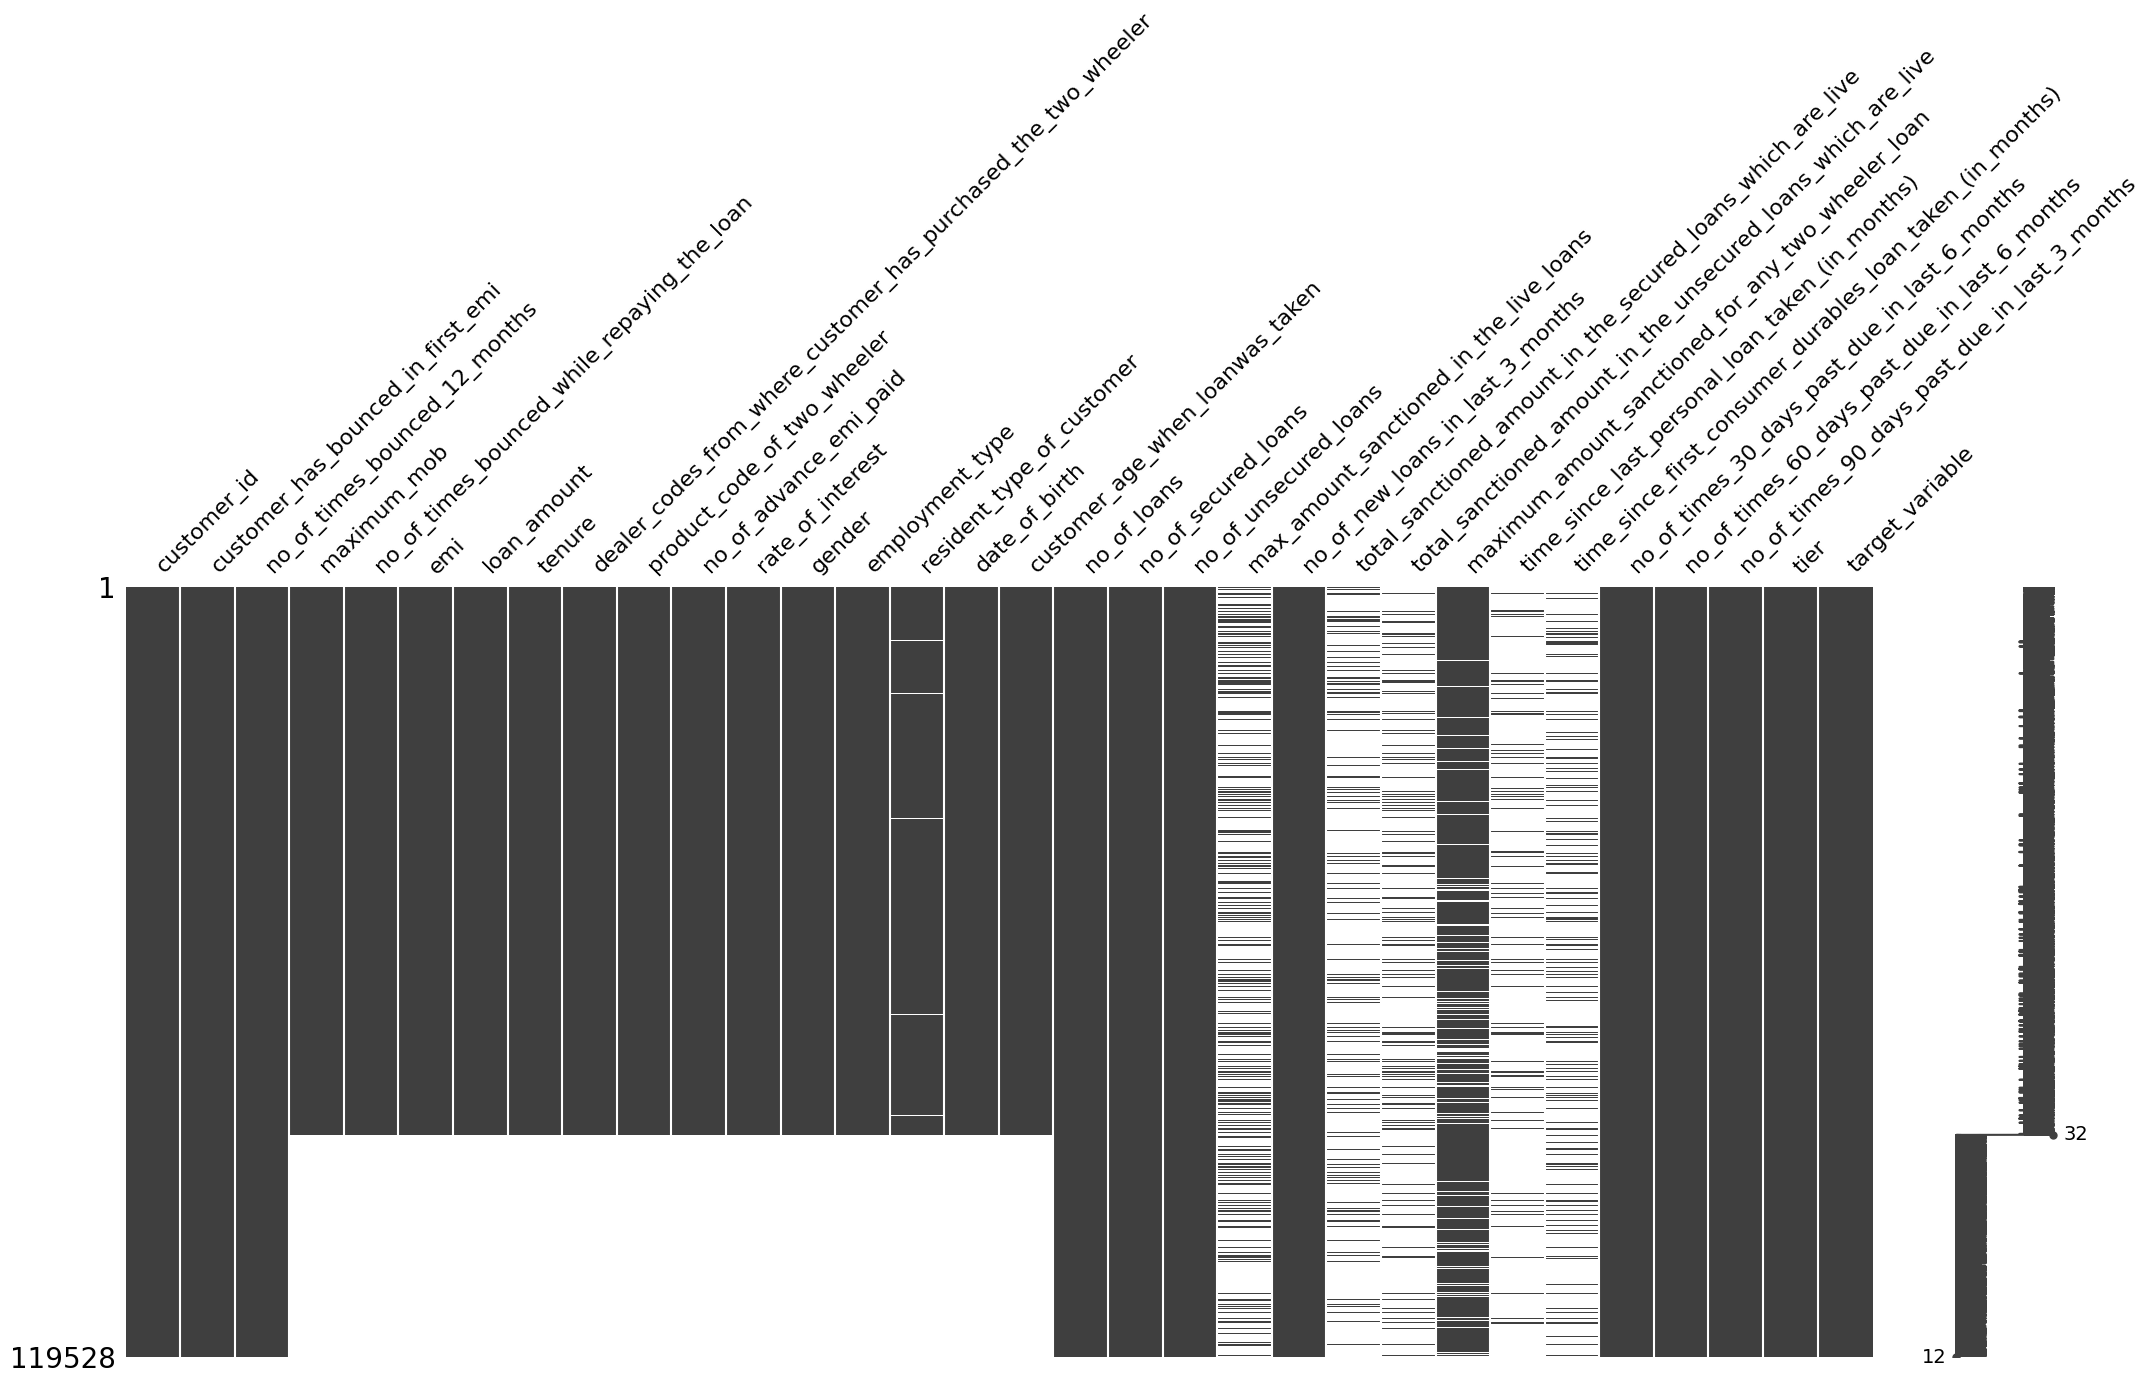

In [8]:
mn.matrix(Loan_renamed)

We are looking to model the probability of loan defaulting, drop all rows with missing loan amount.

In [9]:
# Missing values treatment, drops any row with missing values in the loan and gender column
Loan_renamed.dropna(axis=0,how='any',subset=['loan_amount','gender'],inplace=True)

In [10]:
#Removing irrelevant columns
#I will argue the ID column is also irrelevant
Loan_renamed.drop('customer_id', axis = 1, inplace = True)
Loan_renamed.shape

(85048, 31)

<Axes: >

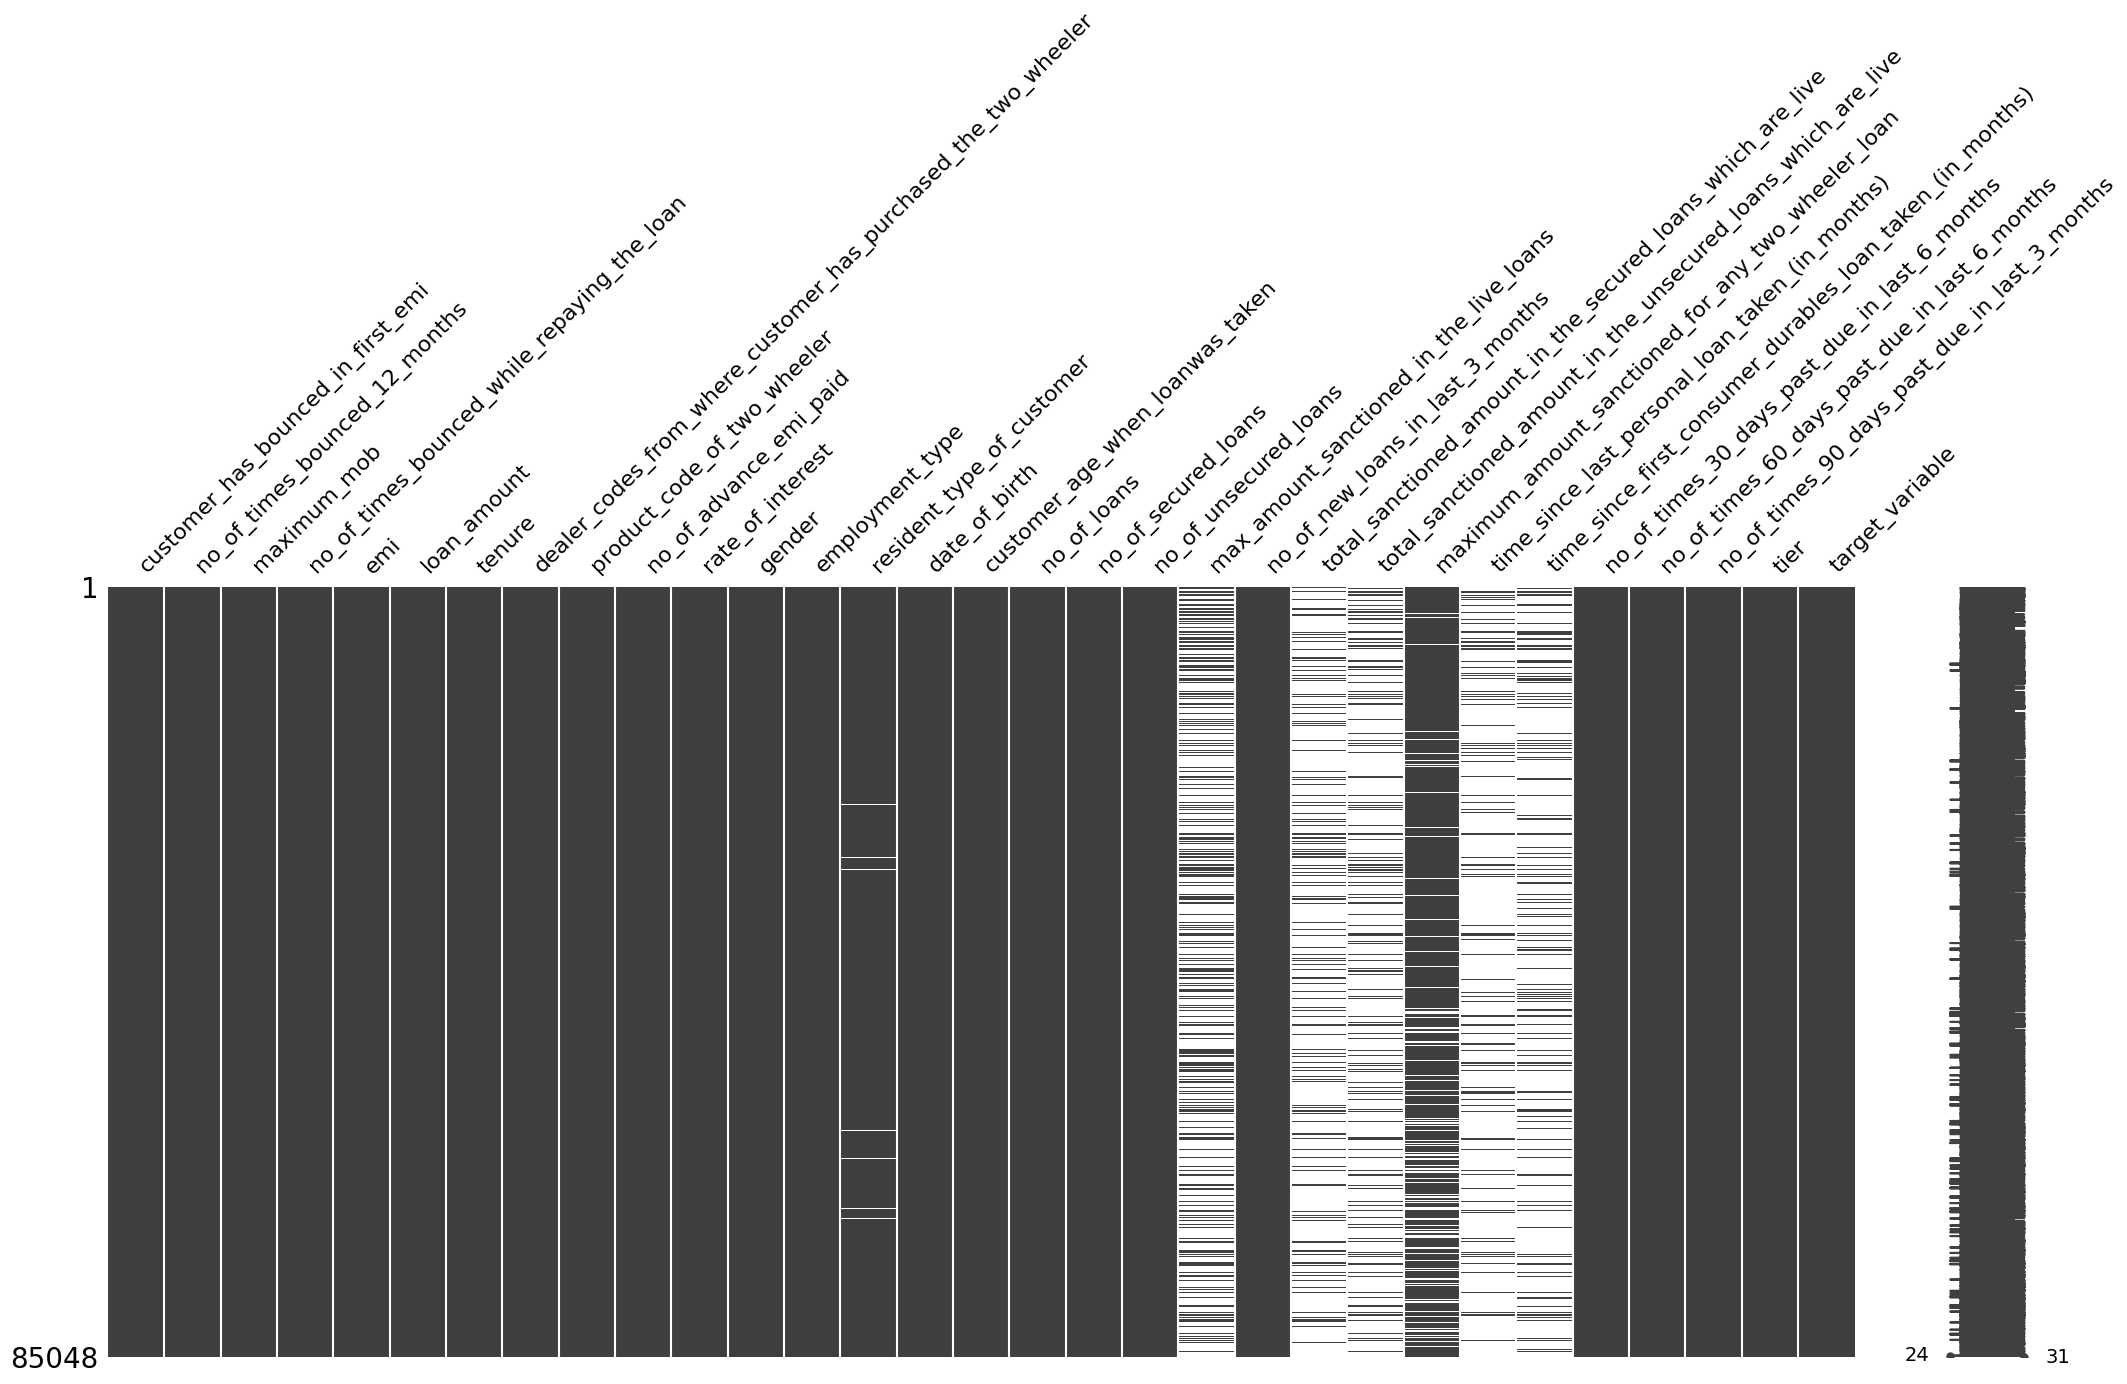

In [11]:
mn.matrix(Loan_renamed)

In [12]:
Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 85048 entries, 0 to 85047
Data columns (total 31 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   customer_has_bounced_in_first_emi                               85048 non-null  int64  
 1   no_of_times_bounced_12_months                                   85048 non-null  int64  
 2   maximum_mob                                                     85048 non-null  float64
 3   no_of_times_bounced_while_repaying_the_loan                     85048 non-null  float64
 4   emi                                                             85048 non-null  float64
 5   loan_amount                                                     85048 non-null  float64
 6   tenure                                                          85048 non-null  float64
 7   dealer_codes_from_where_customer_has_purchased_the_two_wheel

In [13]:
# rows with missing values after drop
Loan_renamed.columns[Loan_renamed.isnull().sum()>0] # columns with missing value present 

Index(['resident_type_of_customer', 'max_amount_sanctioned_in_the_live_loans',
       'total_sanctioned_amount_in_the_secured_loans_which_are_live',
       'total_sanctioned_amount_in_the_unsecured_loans_which_are_live',
       'maximum_amount_sanctioned_for_any_two_wheeler_loan',
       'time_since_last_personal_loan_taken_(in_months)',
       'time_since_first_consumer_durables_loan_taken_(in_months)'],
      dtype='str')

In [14]:
#determine the percent missingness in each column
total_missing=Loan_renamed.isnull().sum().sort_values(ascending=False)
percent=Loan_renamed.isnull().sum().sort_values(ascending=False)/Loan_renamed.isnull().count().sort_values(ascending=False)
missing_df=pd.concat([total_missing,percent],axis=1,keys=['total_missing','percentage_missing'],sort=False)
missing_df.index.name='variable'# set the index name to variable 
missing_df=missing_df[total_missing>0] # only retain those with missing values 
missing_df['percentage_missing']=missing_df['percentage_missing'].map(lambda x:x*100) # convert to percentage 
missing_df

,total_missing,percentage_missing
variable,,
time_since_last_personal_loan_taken_(in_months),75398,88.653466
total_sanctioned_amount_in_the_unsecured_loans_which_are_live,71464,84.027843
total_sanctioned_amount_in_the_secured_loans_which_are_live,71275,83.805616
time_since_first_consumer_durables_loan_taken_(in_months),70504,82.899069
max_amount_sanctioned_in_the_live_loans,58930,69.290283
maximum_amount_sanctioned_for_any_two_wheeler_loan,10730,12.616405
resident_type_of_customer,917,1.078215


 Drop all features that have more than 50% missing values as imputing these features will introduce bias to the model.

In [15]:
drop_cols=missing_df.index[missing_df['percentage_missing']>50].tolist()
drop_cols

['time_since_last_personal_loan_taken_(in_months)',
 'total_sanctioned_amount_in_the_unsecured_loans_which_are_live',
 'total_sanctioned_amount_in_the_secured_loans_which_are_live',
 'time_since_first_consumer_durables_loan_taken_(in_months)',
 'max_amount_sanctioned_in_the_live_loans']

In [16]:
Loan_renamed.drop(columns=drop_cols,inplace=True)
Loan_renamed.shape

(85048, 26)

### 3.2.1 Ploting distributions to address missingness

In [17]:
#split dataframe into numerical data
num_data=Loan_renamed.select_dtypes(include=[np.number])

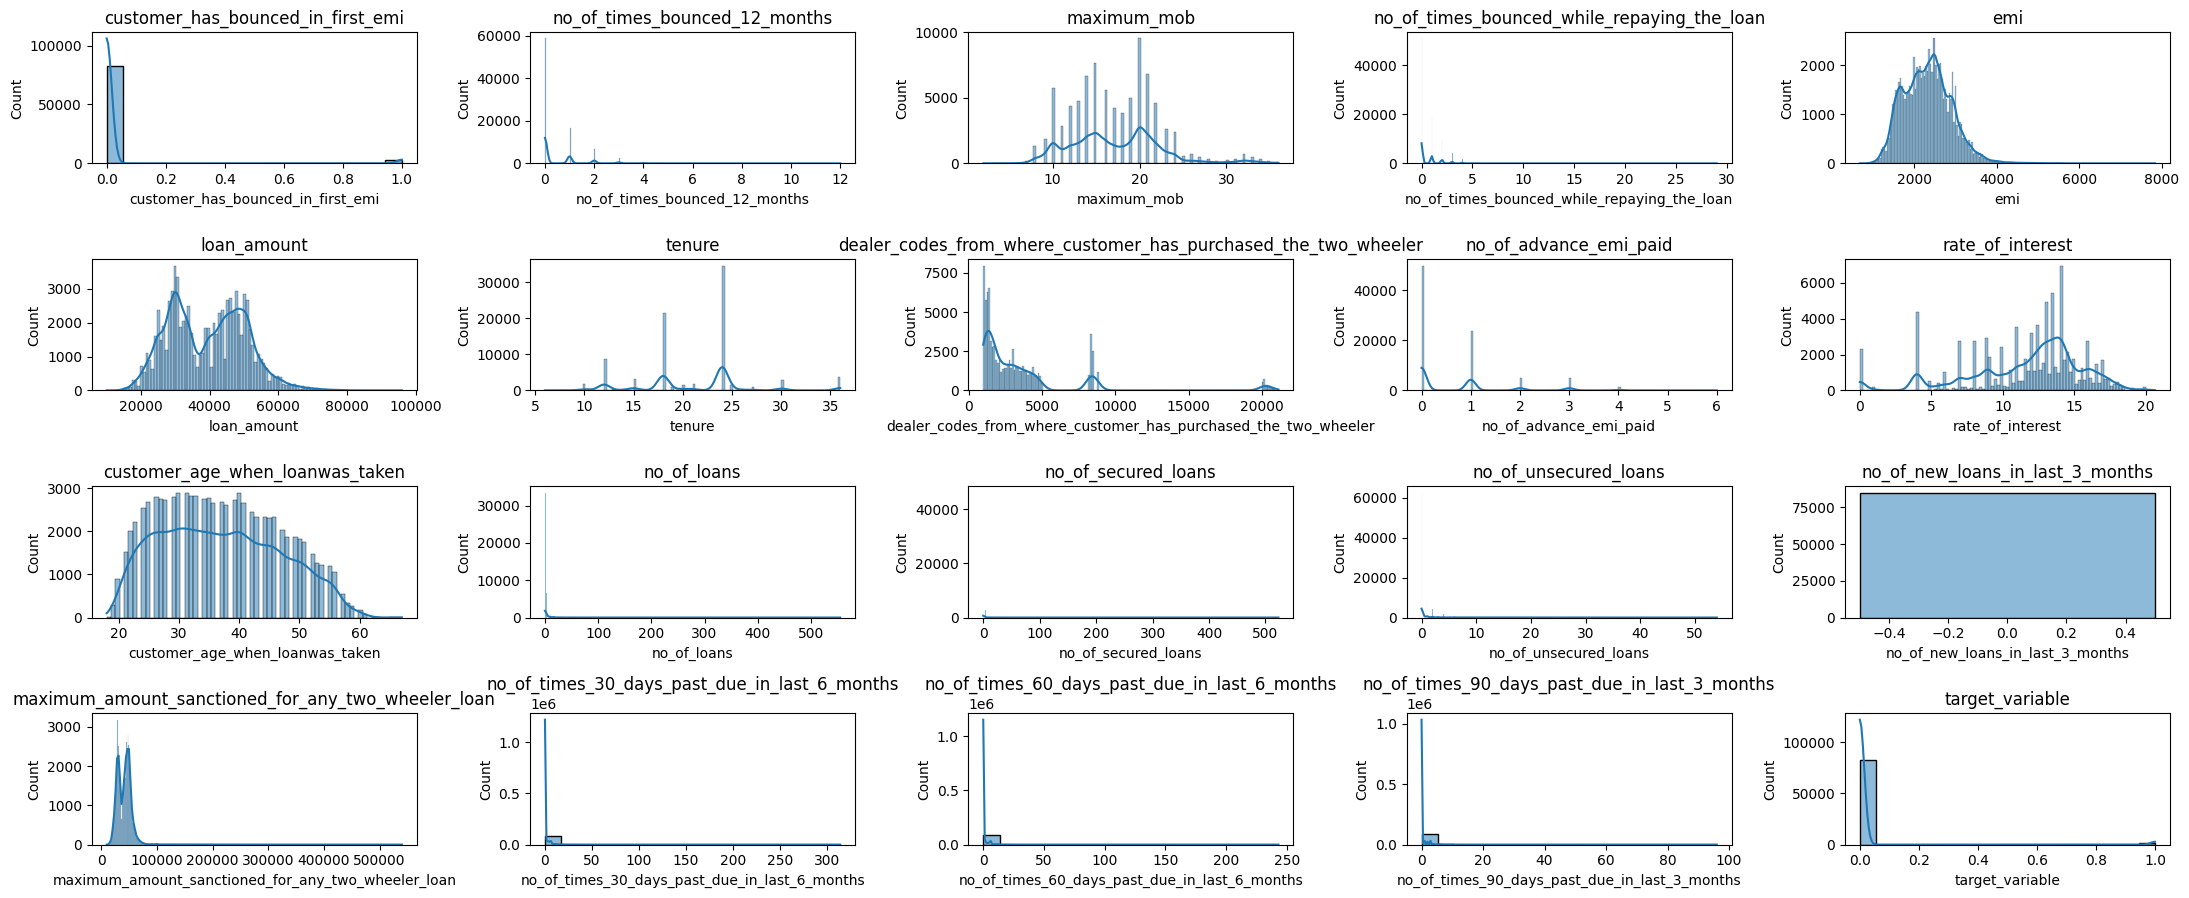

In [18]:
fig = plt.figure(figsize=(22,20))
for i in range(len(num_data.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.histplot(x=num_data.iloc[:, i],ax=ax,kde=True)
    ax.set_title(num_data.columns[i])
    
plt.tight_layout()
plt.show()

#### Insights from Data Distribution:
Most features in the data set follow a bimodal distribution, which means median imputation is preferred for numerical data.
Now, impute missingness with SimpleImputer.SimpleImputer expects a data frame as input, using a single column as input will not work. 

In [19]:
#split into numerical and categorial dfs and impute
#num_df=Loan_renamed.select_dtypes(include=[np.number])

from sklearn.impute import SimpleImputer

imputer=SimpleImputer(missing_values=np.nan,strategy='median')
imputer=imputer.fit(num_data)
numerical_imputed=imputer.transform(num_data)
num_df=pd.DataFrame(numerical_imputed,columns=num_data.columns)


In [20]:
#split into numerical and categorial dfs and impute
cat_df=Loan_renamed.select_dtypes(include=[object])
imputer=SimpleImputer(missing_values=np.nan,strategy='most_frequent')
imputer=imputer.fit(cat_df)
categorical_imputed=imputer.transform(cat_df)
cat_df=pd.DataFrame(categorical_imputed, columns=cat_df.columns)



C:\Users\Wambui\AppData\Local\Temp\ipykernel_6440\3657523560.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df=Loan_renamed.select_dtypes(include=[object])


In [21]:
#concat the numerical and categorical dfs to one
data=pd.concat([cat_df,num_df], axis=1)
data.head()

,product_code_of_two_wheeler,gender,employment_type,resident_type_of_customer,date_of_birth,tier,customer_has_bounced_in_first_emi,no_of_times_bounced_12_months,maximum_mob,no_of_times_bounced_while_repaying_the_loan,...,customer_age_when_loanwas_taken,no_of_loans,no_of_secured_loans,no_of_unsecured_loans,no_of_new_loans_in_last_3_months,maximum_amount_sanctioned_for_any_two_wheeler_loan,no_of_times_30_days_past_due_in_last_6_months,no_of_times_60_days_past_due_in_last_6_months,no_of_times_90_days_past_due_in_last_3_months,target_variable
0,SC,FEMALE,HOUSEWIFE,OWNED,30-05-1974,TIER 1,0.0,0.0,24.0,0.0,...,40.0,1.0,1.0,0.0,0.0,46500.0,0.0,0.0,0.0,0.0
1,MO,MALE,SELF,RENT,01-09-1967,TIER 1,0.0,1.0,24.0,1.0,...,47.0,1.0,1.0,0.0,0.0,28168.0,0.0,0.0,0.0,0.0
2,SC,MALE,SELF,RENT,04-05-1983,TIER 1,0.0,0.0,26.0,0.0,...,31.0,9.0,6.0,3.0,0.0,38900.0,31.0,31.0,16.0,0.0
3,SC,FEMALE,SAL,RENT,10-12-1989,TIER 1,0.0,0.0,24.0,0.0,...,24.0,1.0,1.0,0.0,0.0,42900.0,0.0,0.0,0.0,0.0
4,MC,MALE,SAL,RENT,24-09-1984,TIER 1,0.0,0.0,27.0,0.0,...,30.0,1.0,1.0,0.0,0.0,40900.0,0.0,0.0,0.0,0.0


<Axes: >

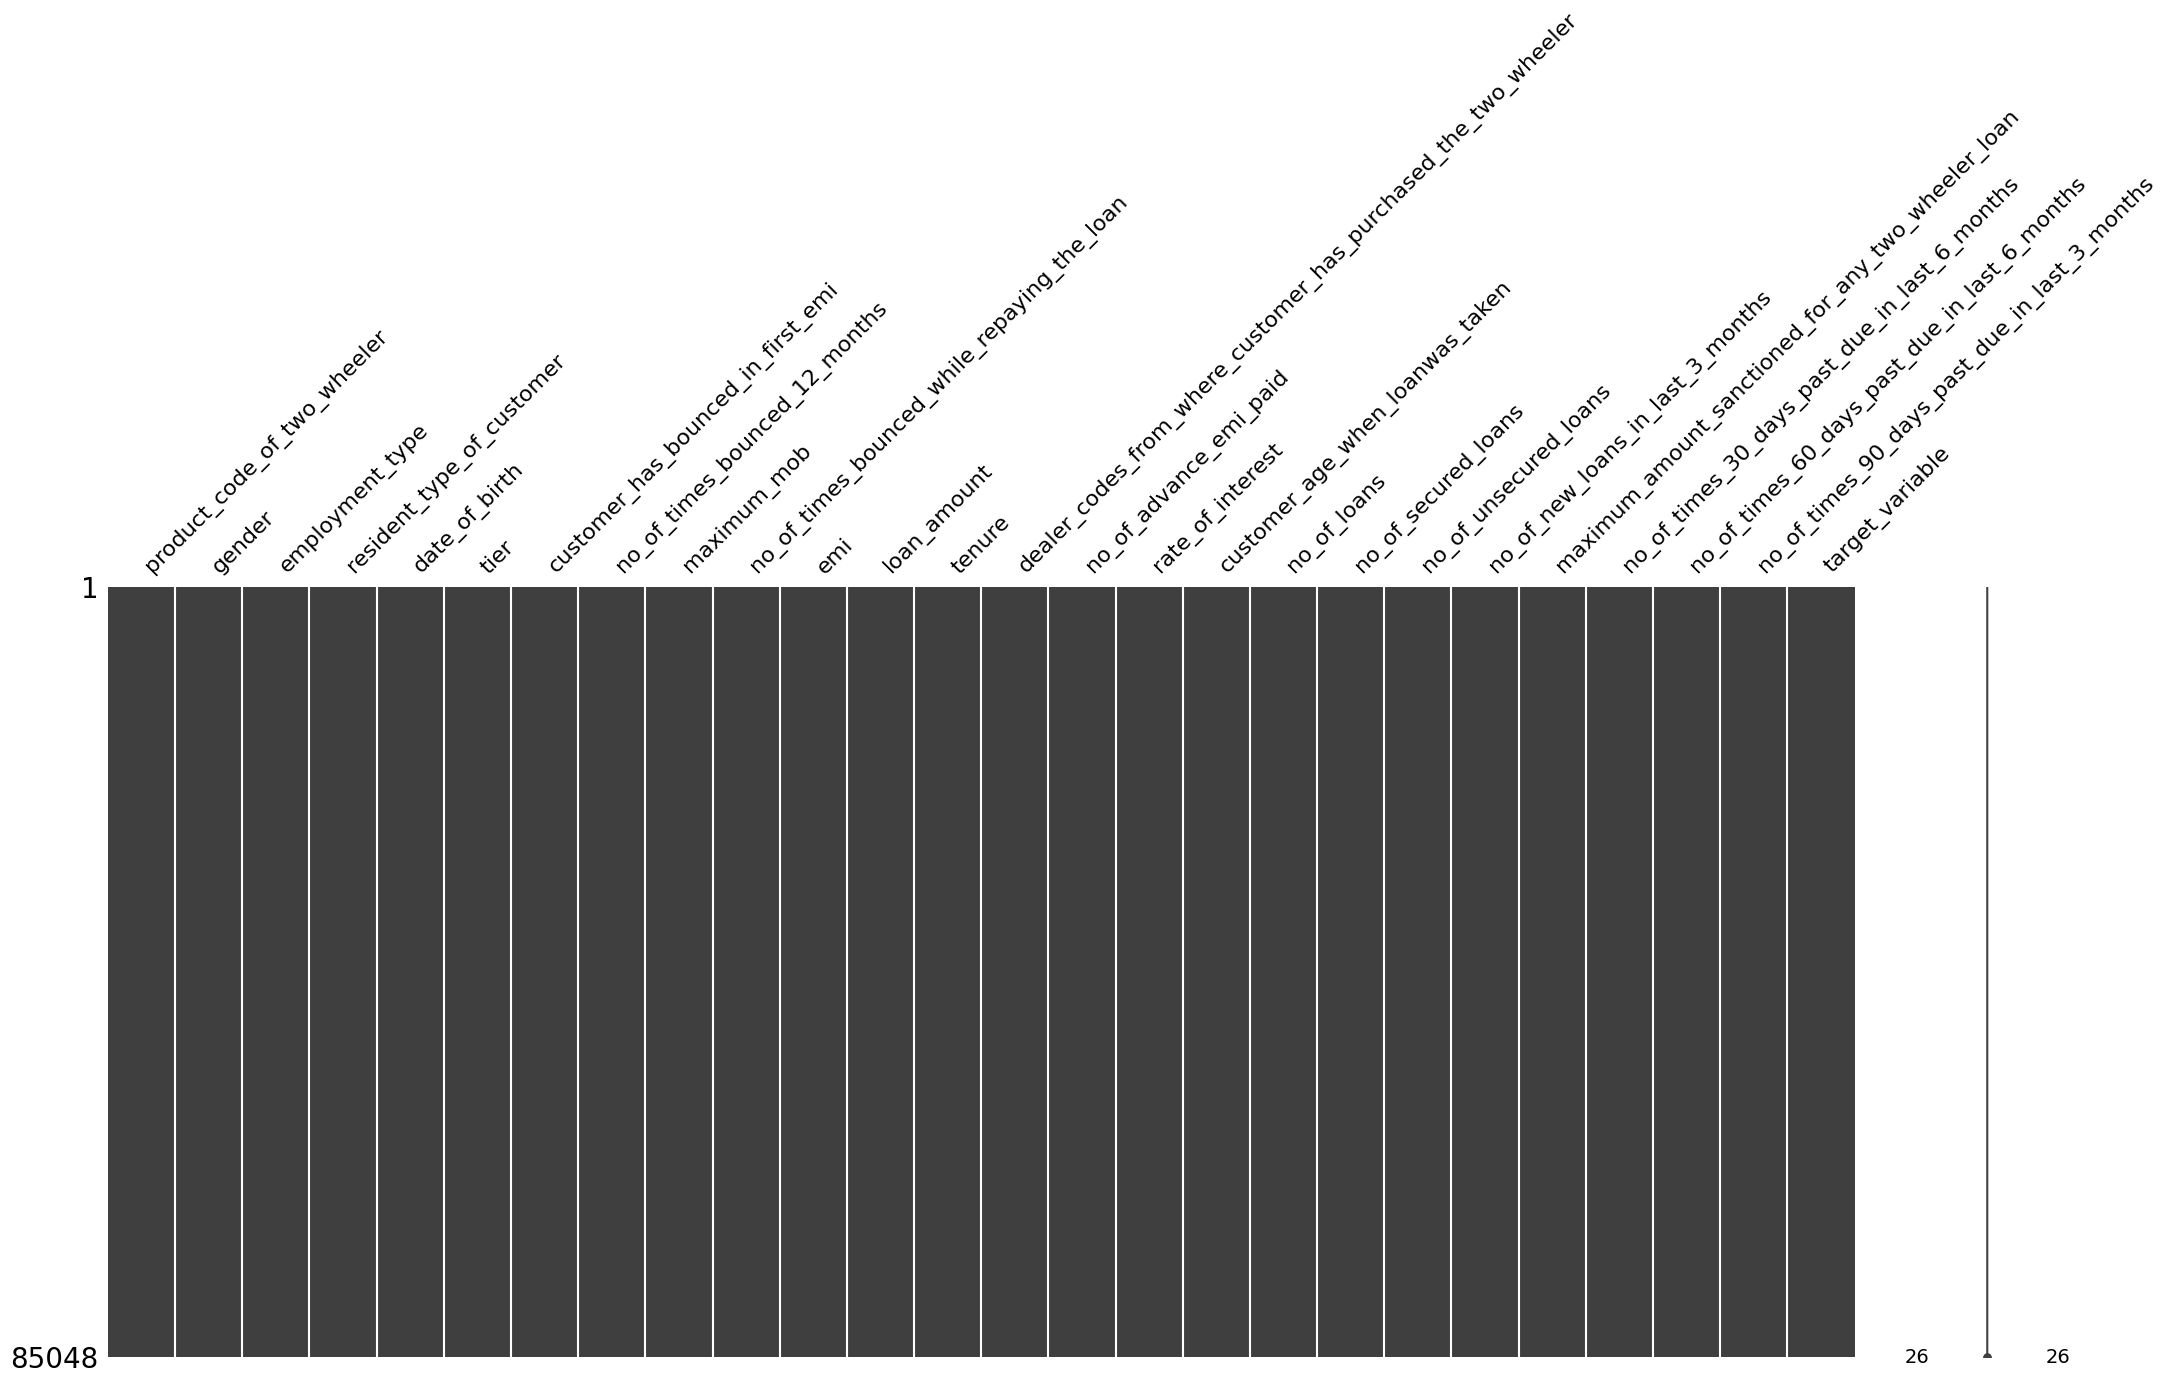

In [22]:
mn.matrix(data)

## 3.3 Outliers

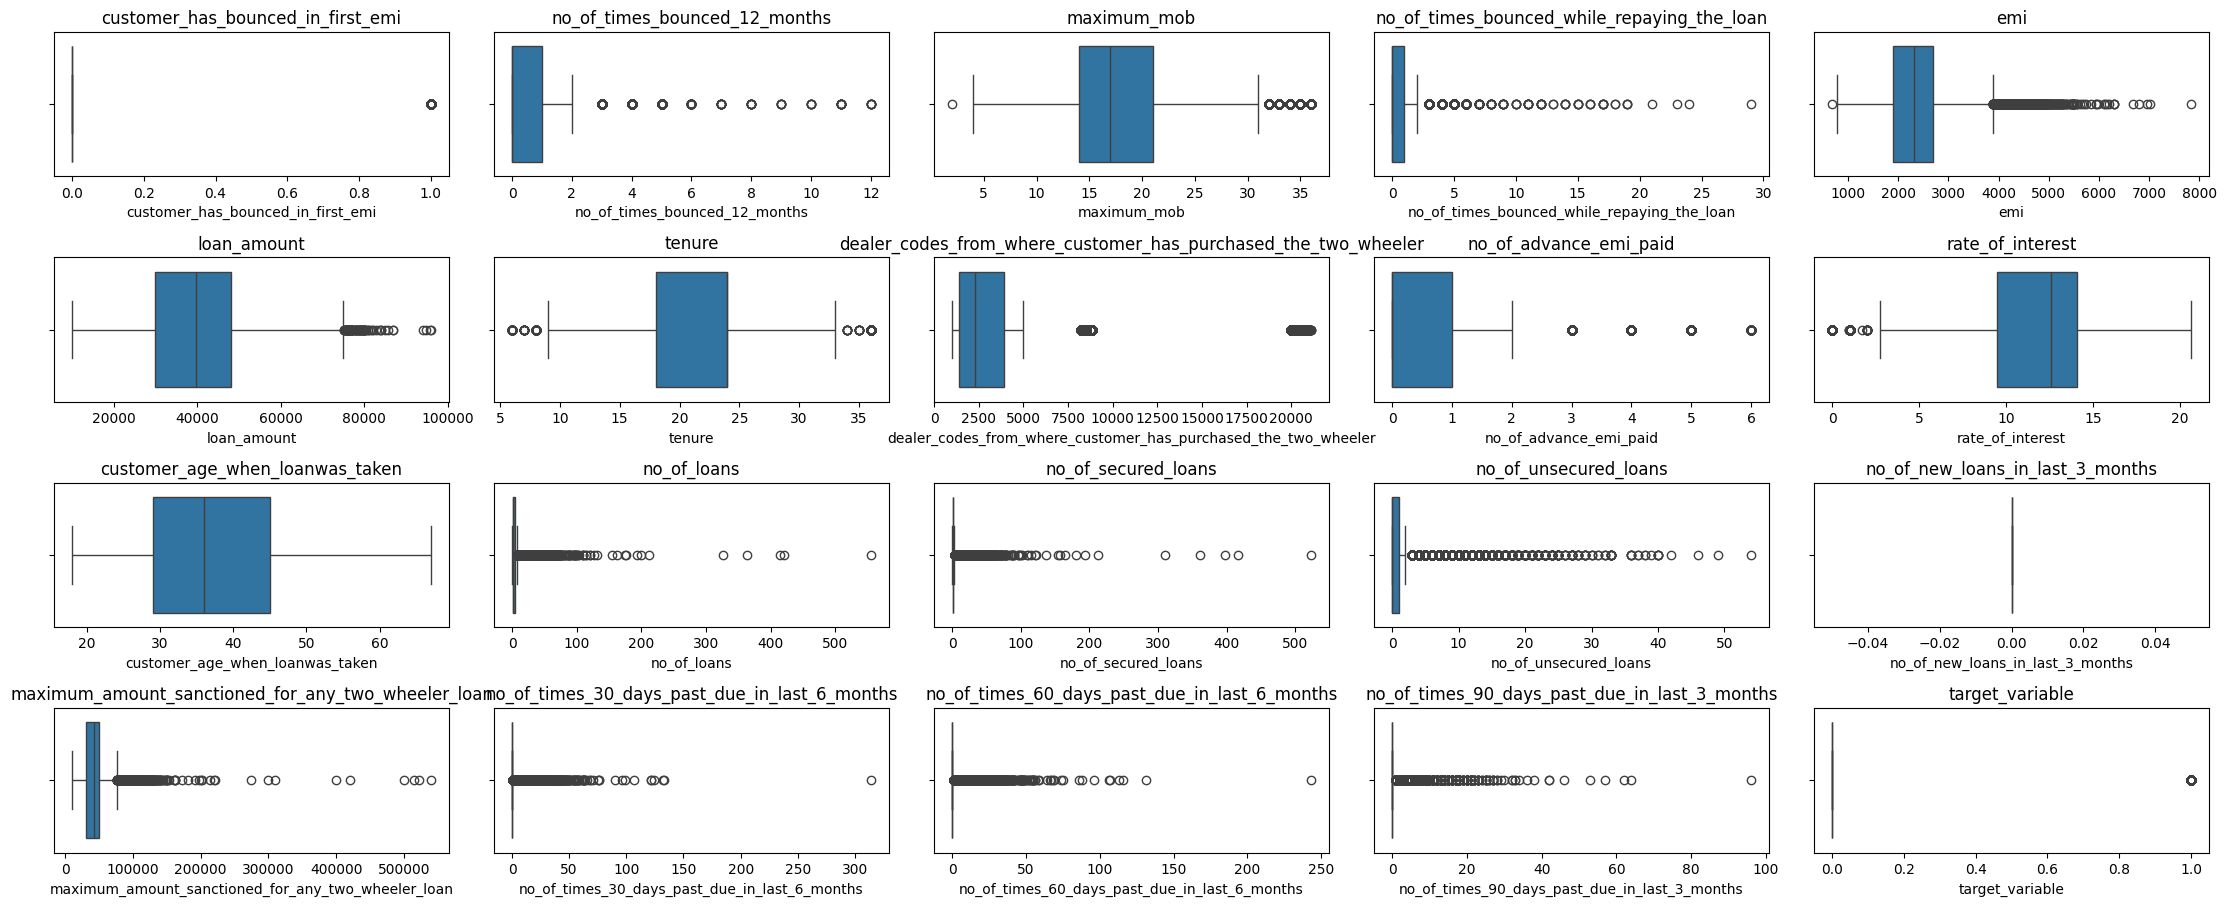

In [23]:
fig = plt.figure(figsize=(22,20))
for i in range(len(num_data.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=num_data.iloc[:, i],ax=ax)
    ax.set_title(num_data.columns[i])
plt.tight_layout()
plt.show()

Numerous features in the data have outliers- the strategy to handle outliers will be to select models that are less sensitive to outliers such as random forest and/or using a robust scaler.

In [24]:
cat_df[['date_of_birth']]

,date_of_birth
0,30-05-1974
1,01-09-1967
2,04-05-1983
3,10-12-1989
4,24-09-1984
...,...
85043,01-07-1969
85044,01-01-1982
85045,01-01-1971
85046,07-11-1961


31/12/2025 and 01/01/2026
31122025 01012026= 300000 approx.

Temporal features are not used in most distance based ML models, unless we use it for feature engineering, maybe extract age from date of birth. However, in our dataset we already have 'age when the loan was taken' as an input feature. This is a more relevant feature compared to someone's current age, so I will go ahead and drop the 'date of birth' feature from the dataset.

In [25]:
cat_df.drop('date_of_birth',axis=1,inplace=True)

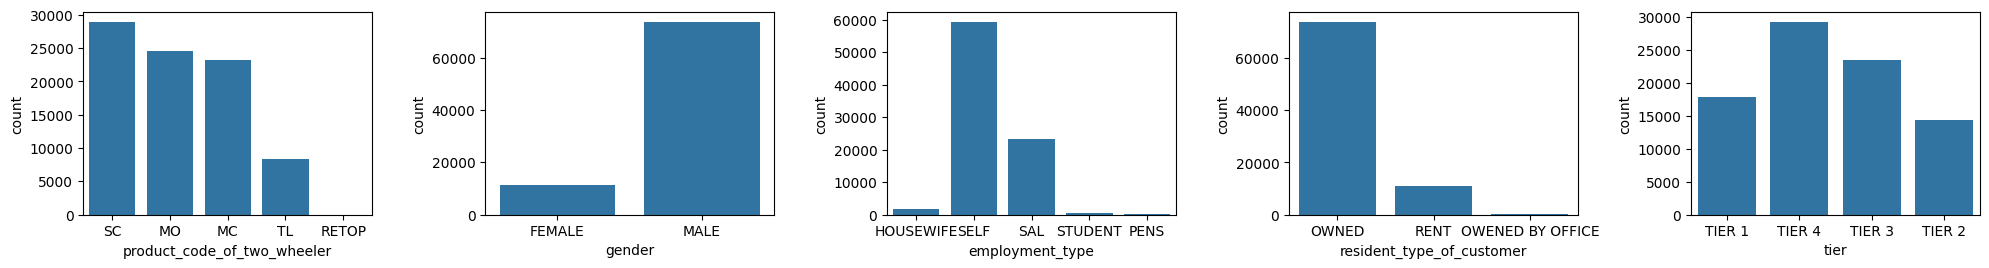

In [26]:
fig = plt.figure(figsize=(20,18))
for i in range(len(cat_df.columns)):
    fig.add_subplot(7, 5, i+1)
    sns.countplot(x=cat_df.iloc[:, i])
plt.tight_layout()
plt.show()

## 3.4 Corelations

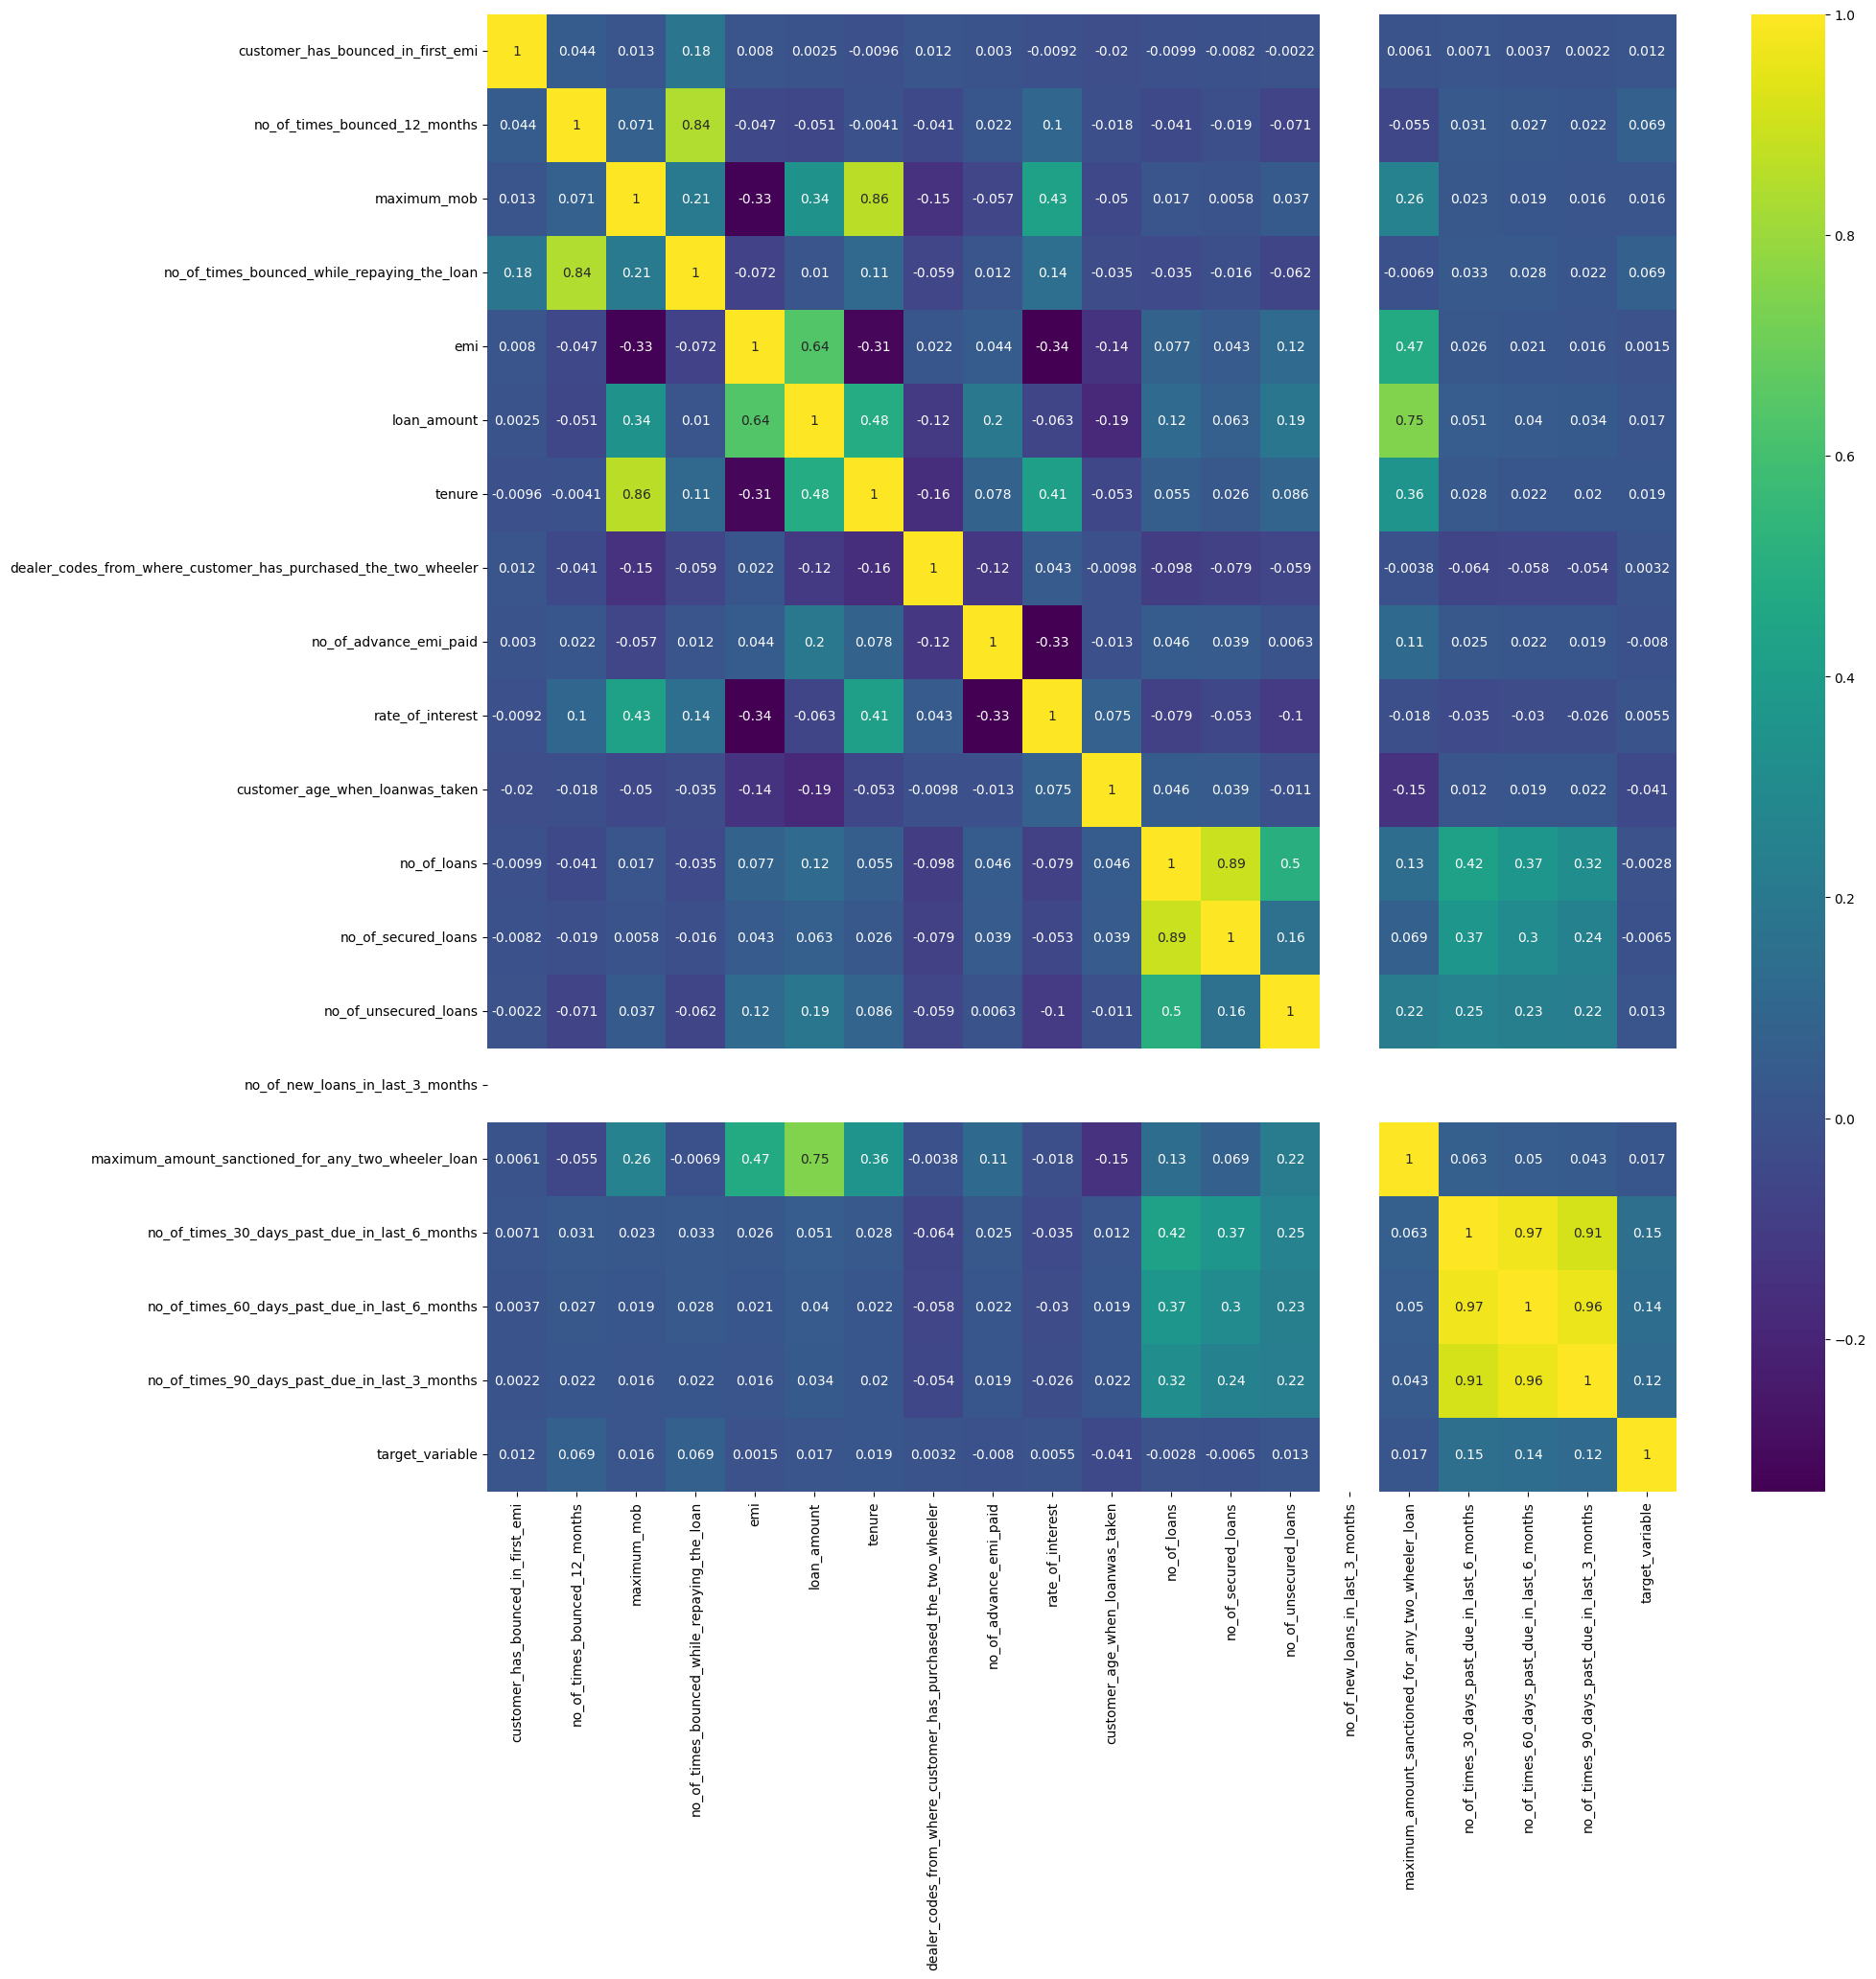

In [27]:
#correlation matrix
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

Investigate why the No of new loans in the last 3 months variable is blank in the matrix- This is because all values are zeros.

In [28]:
data['no_of_new_loans_in_last_3_months']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
85043    0.0
85044    0.0
85045    0.0
85046    0.0
85047    0.0
Name: no_of_new_loans_in_last_3_months, Length: 85048, dtype: float64

Some additional EDA...

<Axes: title={'center': 'Loan Amount (Box Plot)'}, xlabel='employment_type', ylabel='loan_amount'>

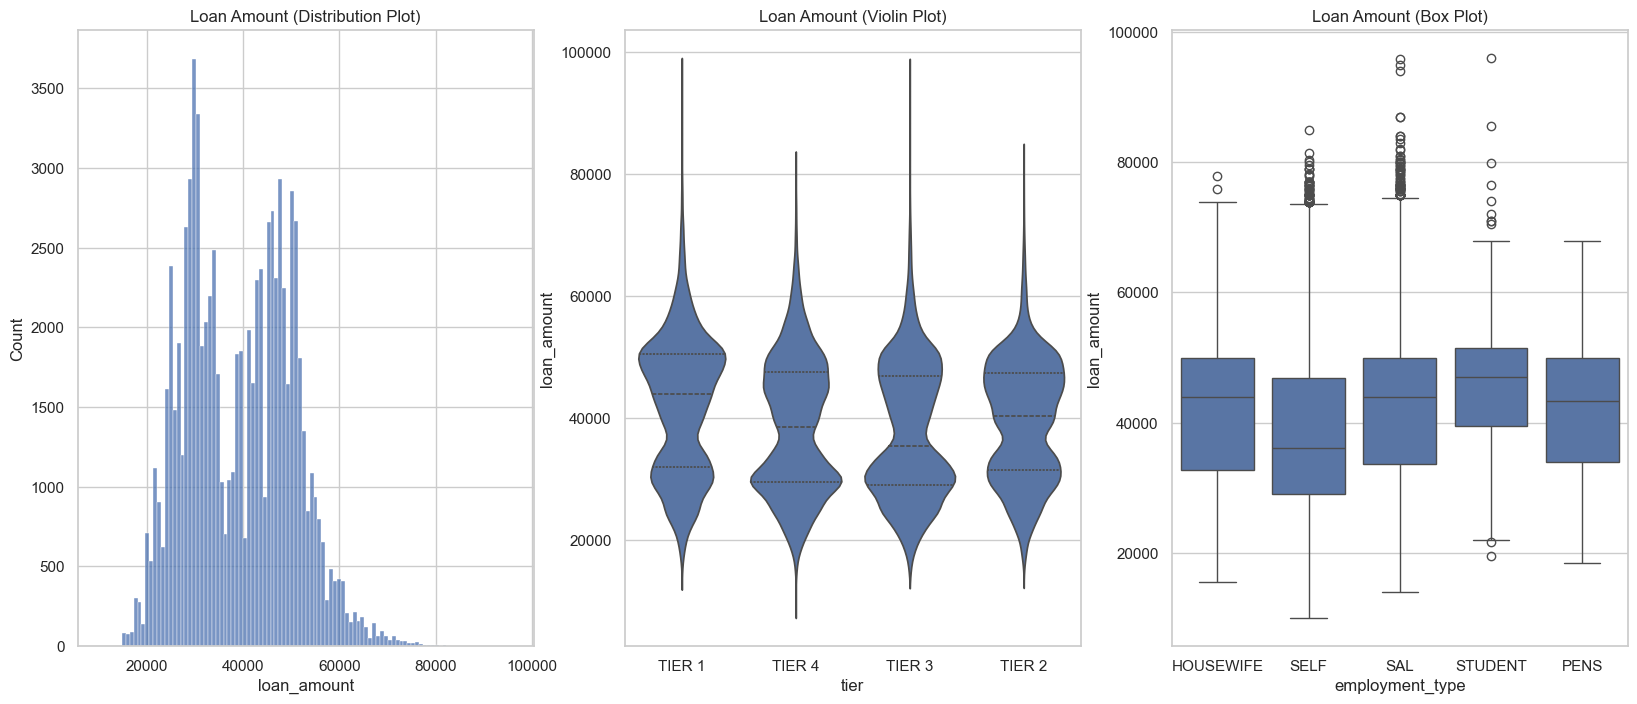

In [29]:
sns.set(style="whitegrid")

fig, ax=plt.subplots(nrows =1,ncols=3,figsize=(20,8))
ax[0].set_title("Loan Amount (Distribution Plot)")
sns.histplot(data['loan_amount'],ax=ax[0])
ax[1].set_title("Loan Amount (Violin Plot)")
sns.violinplot(data =data, x='tier',y='loan_amount',ax=ax[1], inner="quartile")
ax[2].set_title("Loan Amount (Box Plot)")
sns.boxplot(data =data, x='employment_type',y='loan_amount',ax=ax[2],orient='v')

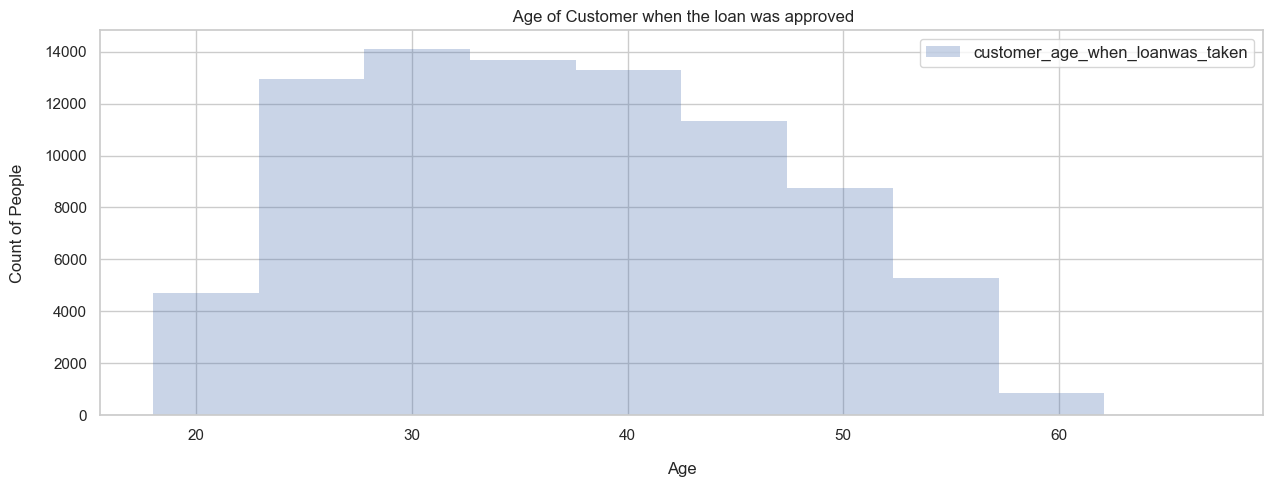

In [30]:
##Age- age at which the client took the loan
plt.figure(figsize=(15,5))

#bar plot
Loan_renamed['customer_age_when_loanwas_taken'].plot(kind='hist',color='b',alpha=0.3, edgecolor='none')
plt.xlabel("Age", labelpad=14)
plt.ylabel("Count of People", labelpad=14)
plt.title(" Age of Customer when the loan was approved")
plt.legend(loc="best",prop={"size":12})

#### Checking for linear Separability

Very key for model selection

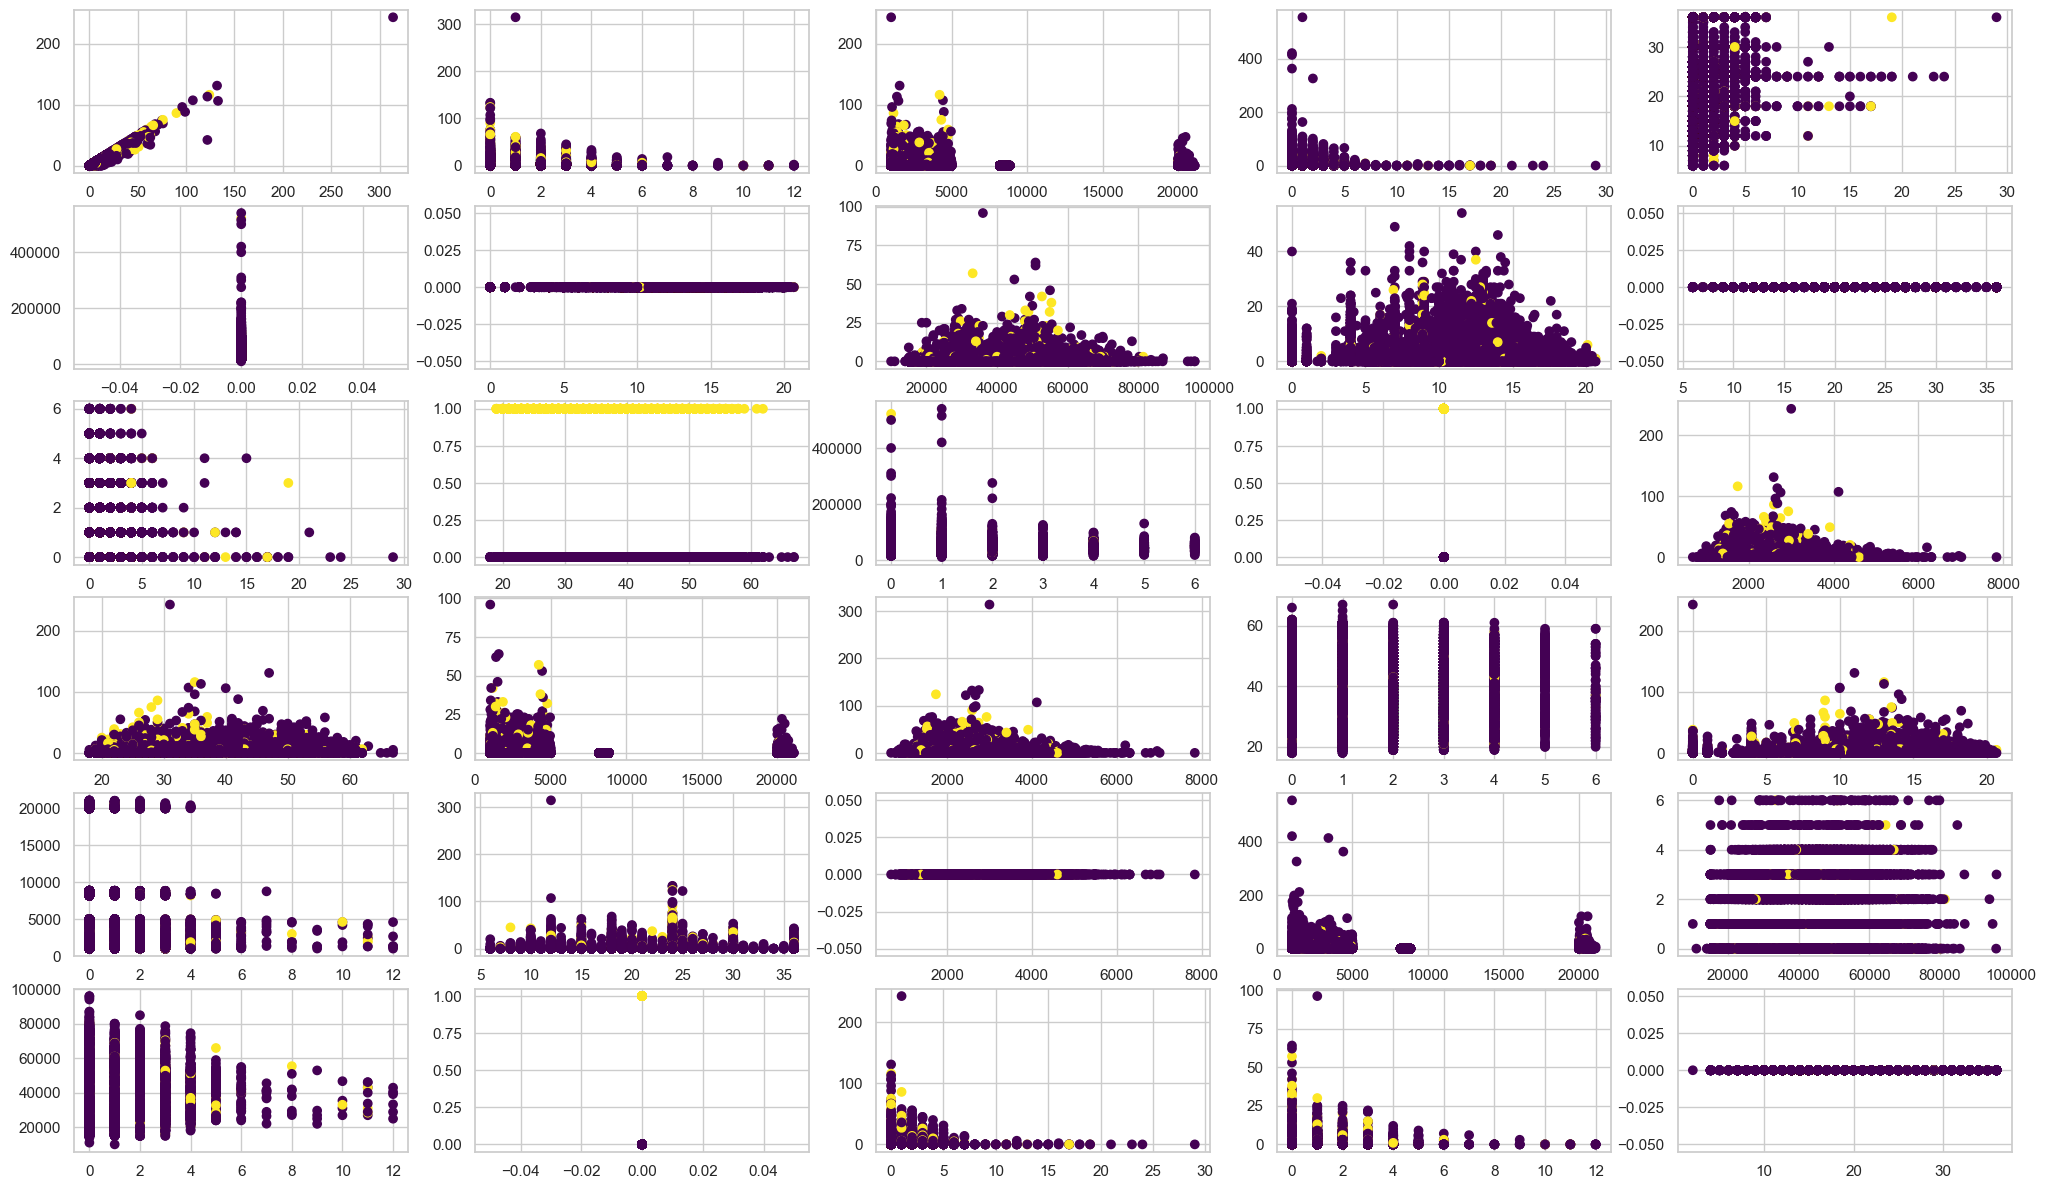

In [31]:
#Check for linear separavility- Bivariate analysis using scatter plots
import random
comb = list(itertools.combinations([a for a in range(1, len(num_df.columns))], 2)) #Create combinations of all features, in twos (bivariate)
rand = random.choices(comb, k=30) #Randomly choose 30 bivariate relationships to visualise. Total bivariate relationships (4060 = 30C3) is too much

fig = plt.figure(figsize=(25,25))
for i in range(len(rand)):
    ax = fig.add_subplot(10,5, i+1)
    plt.scatter(num_df[num_df.columns[rand[i][0]]],num_df[num_df.columns[rand[i][1]]],c=num_df['target_variable'],cmap='viridis')

### Insights from linear separabillity
From the scatter plot, we can conclude that our data is not 
linearly separable. Therefore the best models to perform classification are non-linear classifiers such as SVM with kernels, decision trees, and random forests, logistic regression etc...

# 4. Data Preprocessing

### 4.1 Encoding

1. Label encoding
We can use LabelEncoder to encode our variable to numbers. What a label encoder essentially does is that it sees the first value in the column and converts it to 0, next value to 1 and so on.The integer values have a natural ordered relationship between each other and machine learning algorithms may be able to understand and harness this relationship. This approach works reasonably well with tree models

2. One hot encoding
For categorical variables where no such ordinal relationship exists, the integer/label encoding does not suffice. In fact, using this encoding and allowing the model to assume a natural ordering between categories may result in poor performance or unexpected results (predictions halfway between categories).

In this case, I will opt for the Onehote encoding , though I did not want to increase the dimensionality of my dataset, I did not want my model to assume any natural order in the encoding values.


In [32]:
# Dealing with categorical columns
# Label Encoding for object to numeric conversion
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

encoded=ohe.fit_transform(cat_df.astype(str))
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cat_df.columns))
encoded_df.head()

,product_code_of_two_wheeler_MC,product_code_of_two_wheeler_MO,product_code_of_two_wheeler_RETOP,product_code_of_two_wheeler_SC,product_code_of_two_wheeler_TL,gender_FEMALE,gender_MALE,employment_type_HOUSEWIFE,employment_type_PENS,employment_type_SAL,employment_type_SELF,employment_type_STUDENT,resident_type_of_customer_OWENED BY OFFICE,resident_type_of_customer_OWNED,resident_type_of_customer_RENT,tier_TIER 1,tier_TIER 2,tier_TIER 3,tier_TIER 4
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [33]:
final_df=pd.concat([encoded_df,num_df],axis=1)
final_df.head()

,product_code_of_two_wheeler_MC,product_code_of_two_wheeler_MO,product_code_of_two_wheeler_RETOP,product_code_of_two_wheeler_SC,product_code_of_two_wheeler_TL,gender_FEMALE,gender_MALE,employment_type_HOUSEWIFE,employment_type_PENS,employment_type_SAL,...,customer_age_when_loanwas_taken,no_of_loans,no_of_secured_loans,no_of_unsecured_loans,no_of_new_loans_in_last_3_months,maximum_amount_sanctioned_for_any_two_wheeler_loan,no_of_times_30_days_past_due_in_last_6_months,no_of_times_60_days_past_due_in_last_6_months,no_of_times_90_days_past_due_in_last_3_months,target_variable
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,40.0,1.0,1.0,0.0,0.0,46500.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,47.0,1.0,1.0,0.0,0.0,28168.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,31.0,9.0,6.0,3.0,0.0,38900.0,31.0,31.0,16.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,24.0,1.0,1.0,0.0,0.0,42900.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,30.0,1.0,1.0,0.0,0.0,40900.0,0.0,0.0,0.0,0.0


### 4.2 Treating Class Imbalance

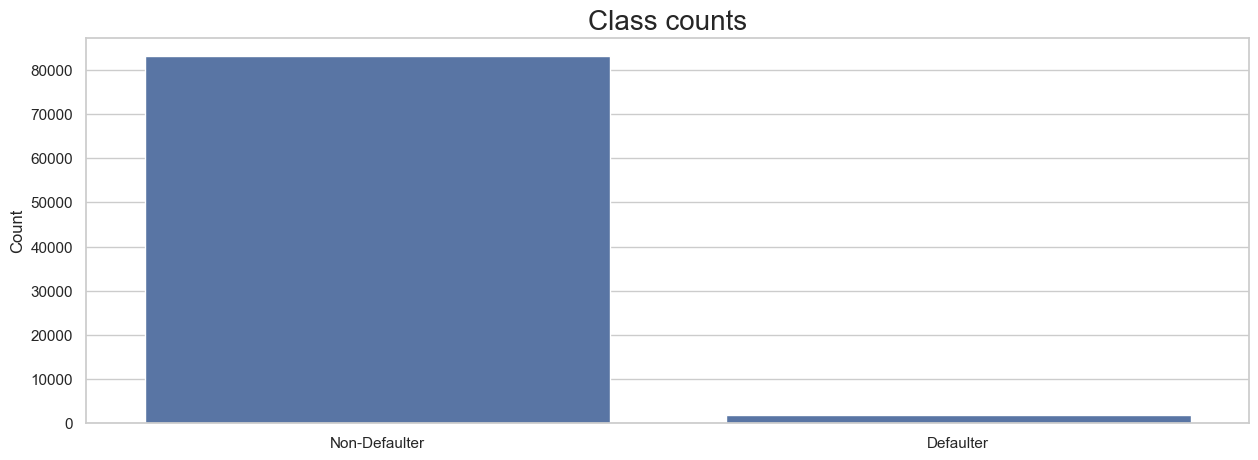

In [34]:
fig=plt.figure(figsize=(15,5))
sns.countplot(x='target_variable',data=data)
plt.xticks((0, 1), ["Non-Defaulter", "Defaulter"])
plt.xlabel("")
plt.ylabel("Count")
plt.title("Class counts",fontdict={"fontsize": 20})

plt.show()

data point X
data point Y

The data set is pretty imbalanced as expected where positive examples defualters are significanltly less than 25%. We'll explain in the next section how to handle all of them after giving an overview of ensemble methods


### SMOTE
S𝒚𝒏𝒕𝒉𝒆𝒕𝒊𝒄 𝒎𝒊𝒏𝒐𝒓𝒊𝒕𝒚 𝒐𝒗𝒆𝒓𝒔𝒂𝒎𝒑𝒍𝒊𝒏𝒈 𝒕𝒆𝒄𝒉𝒏𝒊𝒒𝒖𝒆- creates examples of the minority class by looking at the distribution of the minority class and "guesses" what the other cases would have been

pick two points that are relatively closer to each other distance wise
draw a line
generate a new point along that line
It doesn't always work but a lot of time it works and it is a good technique to look at when there is no way of generating more data and the aforementioned techniques are not applicable per se It is better for increasing precision(𝙥𝙤𝙨𝙞𝙩𝙞𝙫𝙚 𝙞𝙙𝙚𝙣𝙩𝙞𝙛𝙞𝙚𝙙 𝙖𝙨 𝒕𝒉𝒂𝒕 𝒂𝒓𝒆 𝒑𝒐𝒔𝒊𝒕𝒊𝒗𝒆 ) but this comes at the cost of recall (𝒐𝒖𝒕 𝒐𝒇 𝒂𝒍𝒍 𝒕𝒉𝒆 𝒑𝒐𝒔𝒊𝒕𝒊𝒗𝒆𝒔 𝒘𝒉𝒊𝒄𝒉 𝒐𝒏𝒆𝒔 𝒉𝒂𝒗𝒆 𝒃𝒆𝒆𝒏 𝒄𝒐𝒓𝒓𝒆𝒄𝒕𝒍𝒚 𝒊𝒅𝒆𝒏𝒕𝒊𝒇𝒊𝒆𝒅)

SMOTE is ONLY applied to the training dataset, so before you fix the class imbalance make sure to spilt your dataset to prevent data leakage.

In [35]:
X=final_df.drop('target_variable',axis=1)
y=final_df[['target_variable']]

In [36]:
#Train Test Split: Reserve 20% of data for final model testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(68038, 38) (17010, 38) (68038, 1) (17010, 1)


array([[<Axes: title={'center': 'target_variable'}>]], dtype=object)

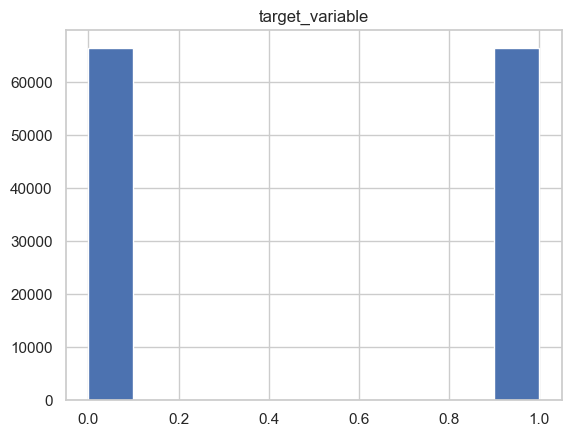

In [37]:
# Class Imbalance
from imblearn.over_sampling import SMOTE

smote_sample=SMOTE(random_state=124,sampling_strategy='auto')
# the sampling strategy can be one of float, str, dict or callable `float``,
#it corresponds to the desired ratio of the number of samples in the minority class over the number of samples in the majority class after resampling ie {1:500}
# ``'minority'``: resample only  minority class; 'not minority'``:all but the minority class; ``'not majority'``: all but the majority, ``'all'`` ,``'auto'``:
x_res, y_res=smote_sample.fit_resample(X_train,y_train)


# now plot the classes
y_res.hist()

# 5. Modelling with the balanced data


In [38]:
#SCALE THE FEATURES
from sklearn.preprocessing import RobustScaler, StandardScaler

scaler = RobustScaler()
X_train_scaled= scaler.fit_transform(x_res)
X_test_scaled= scaler.transform(X_test)

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import fbeta_score , make_scorer


rf = RandomForestClassifier(n_estimators=50, random_state=42) 
f2_scorer = make_scorer(fbeta_score, beta=2)
scores = cross_val_score(
    rf,            
    X_train_scaled,       
    y_res.values.ravel(),        
    cv=5,         
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.91226696 0.99918881 0.99938407 0.99939908 0.99948929]
Mean Fbeta score: 0.9819456433572785


In [39]:
#now try a logistic regression classifier

from sklearn.linear_model import LogisticRegression

lrc=LogisticRegression(random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    lrc,
    X_train_scaled,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.7425826  0.74840229 0.75       0.75152787 0.7463635 ]
Mean Fbeta score: 0.7477752513011205


In [40]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    ada,
    X_train_scaled,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.89823165 0.97398792 0.97938377 0.97369965 0.97788554]
Mean Fbeta score: 0.9606377054336953


#### Try it yourself!!!!
1. Try other non-linear classification models such as support vector machines with kernel functions, Logistic Regression with regularization and other ensemble methods such as XGBoost etc...

#### Selecting the best performing candidate model

When it comes to choosing the best candidate model in classification tasks, it is not enough to rely on one single metric like recall, precision etc...(But please note, the choice in evaluation metric should align with the business case). For classification, we take it a step further and look at the model performance per class- in this case, I want a model that is really good at identifying defaulters- because there is where the money is, this is the actual business value of the ML model.

So we print the classification report of each model and see how good they are at minimizing false negative and then use the ROC-AUC curve to choose the best performing model.

In [41]:
from sklearn.metrics import classification_report

rf.fit(X_train_scaled, y_res.values.ravel())
y_pred = rf.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=["Defaulters", "Non-defaulters"]))

                precision    recall  f1-score   support

    Defaulters       0.98      1.00      0.99     16656
Non-defaulters       0.39      0.04      0.08       354

      accuracy                           0.98     17010
     macro avg       0.69      0.52      0.53     17010
  weighted avg       0.97      0.98      0.97     17010



In [42]:
lrc.fit(X_train_scaled, y_res.values.ravel())
y_pred = lrc.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=["Defaulters", "Non-defaulters"]))

                precision    recall  f1-score   support

    Defaulters       0.99      0.83      0.90     16656
Non-defaulters       0.08      0.68      0.14       354

      accuracy                           0.82     17010
     macro avg       0.53      0.75      0.52     17010
  weighted avg       0.97      0.82      0.89     17010



In [43]:
ada.fit(X_train_scaled, y_res.values.ravel())
y_pred = ada.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=["Defaulters", "Non-defaulters"]))

                precision    recall  f1-score   support

    Defaulters       0.98      0.98      0.98     16656
Non-defaulters       0.21      0.25      0.23       354

      accuracy                           0.96     17010
     macro avg       0.60      0.61      0.60     17010
  weighted avg       0.97      0.96      0.97     17010



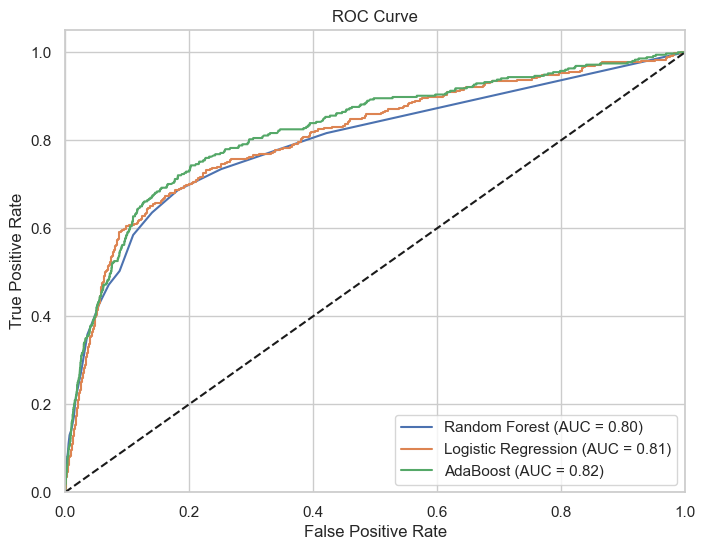

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# calculate the probabilities for the positive class (class 1) for each model
y_prob_rf=rf.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')


y_prob_lrc=lrc.predict_proba(X_test_scaled)[:,1]
fpr_lrc, tpr_lrc, _ = roc_curve(y_test, y_prob_lrc)
roc_auc_lrc = roc_auc_score(y_test, y_prob_lrc)
plt.plot(fpr_lrc, tpr_lrc, label=f'Logistic Regression (AUC = {roc_auc_lrc:.2f})')

y_prob_ada=ada.predict_proba(X_test_scaled)[:,1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
roc_auc_ada = roc_auc_score(y_test, y_prob_ada)
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {roc_auc_ada:.2f})')



plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend()
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

Which model should we choose?

## HyperParameter Tuning

In [45]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [46]:
'''params_grid={
    'bootstrap':[False, True],
    'max_depth': [8,10,15,20],
    'min_samples_split':[2,10,15],
    'n_estimators':[50,100,200]
}'''

"params_grid={\n    'bootstrap':[False, True],\n    'max_depth': [8,10,15,20],\n    'min_samples_split':[2,10,15],\n    'n_estimators':[50,100,200]\n}"

In [47]:
'''from sklearn.model_selection import   GridSearchCV, RandomizedSearchCV
f2_score=make_scorer(fbeta_score,beta=2)

rfc=RandomForestClassifier()
grid_search=GridSearchCV(estimator=rfc,param_grid=params_grid,cv=5,scoring=f2_score).fit(X_train,y_train.values.ravel())
print(grid_search.best_params_)'''

'from sklearn.model_selection import   GridSearchCV, RandomizedSearchCV\nf2_score=make_scorer(fbeta_score,beta=2)\n\nrfc=RandomForestClassifier()\ngrid_search=GridSearchCV(estimator=rfc,param_grid=params_grid,cv=5,scoring=f2_score).fit(X_train,y_train.values.ravel())\nprint(grid_search.best_params_)'

Now, retrain your model on the best parameters.

In [48]:
'''model = grid_search.best_estimator_

    y_pred = model.predict(X_test_scaled)
    print(fbeta_score(y_test, y_pred, beta=2))'''

'model = grid_search.best_estimator_\n\n    y_pred = model.predict(X_test_scaled)\n    print(fbeta_score(y_test, y_pred, beta=2))'

My model is clearly overfitting to the training set. This could be because of the kinds of parameters I have given it, Bootstratp =False, means each tree uses the entire dataset which makes overfitting worse and also, the trees could be too deep- 20 layers is a lot.

Next logical, step is to make the params grid stricter and conduct hyperparameter tuning again

In [49]:
params_grid = {
    'bootstrap': [True],          
    'max_depth': [4, 6, 8, 10],   
    'min_samples_split': [10, 20, 50],  
    'min_samples_leaf': [5, 10, 20],    
    'n_estimators': [100, 200]
}

In [50]:
from sklearn.model_selection import   GridSearchCV, RandomizedSearchCV
f2_score=make_scorer(fbeta_score,beta=2)

rfc=RandomForestClassifier()
grid_search=GridSearchCV(estimator=rfc,param_grid=params_grid,cv=5,scoring=f2_score).fit(X_train,y_train.values.ravel())
print(grid_search.best_params_)

{'bootstrap': True, 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}


In [59]:
model = grid_search.best_estimator_

model.fit(X_train_scaled, y_res.values.ravel())
y_pred = model.predict(X_test_scaled)
print(fbeta_score(y_test, y_pred, beta=2))
print(classification_report(y_test, y_pred, target_names=["Defaulters", "Non-defaulters"]))


0.26976495726495725
                precision    recall  f1-score   support

    Defaulters       0.99      0.87      0.93     16656
Non-defaulters       0.09      0.57      0.15       354

      accuracy                           0.87     17010
     macro avg       0.54      0.72      0.54     17010
  weighted avg       0.97      0.87      0.91     17010



In [60]:
#save the model using pickle
import pickle
with open('credit_risk_model.pkl', 'wb') as file:
    pickle.dump(model, file)

## Model Evaluation & Explainability

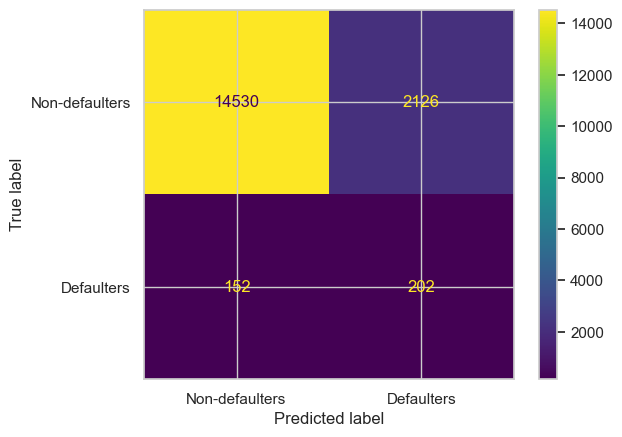

In [61]:
# plot the confusion matrix of the random forest classifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Non-defaulters','Defaulters'])
disp.plot()
plt.show()

In [ ]:
#do we get a better ROC-AUC score with the tuned model?
y_prob_model=model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_prob_model)
print(f'Random Forest ROC-AUC score = {roc_auc:.2f}')

Random Forest ROC-AUC score = 0.82)


### Error Analysis with SHAP

In [41]:
#load the saved model
import pickle
with open("credit_risk_model.pkl", "rb") as f:
    model = pickle.load(f)

In [75]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [76]:
feature_names = X.columns.tolist()

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

In [93]:
#construct the explainer and calculate SHAP values for the test set
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

In [95]:
shap_values.shape

(17010, 38, 2)

In [78]:
# stack all customers into one matrix then take the defaulter class
shap_values_defaulter = np.stack(shap_values)[:, :, 1]

print(shap_values_defaulter.shape)  

(17010, 38)


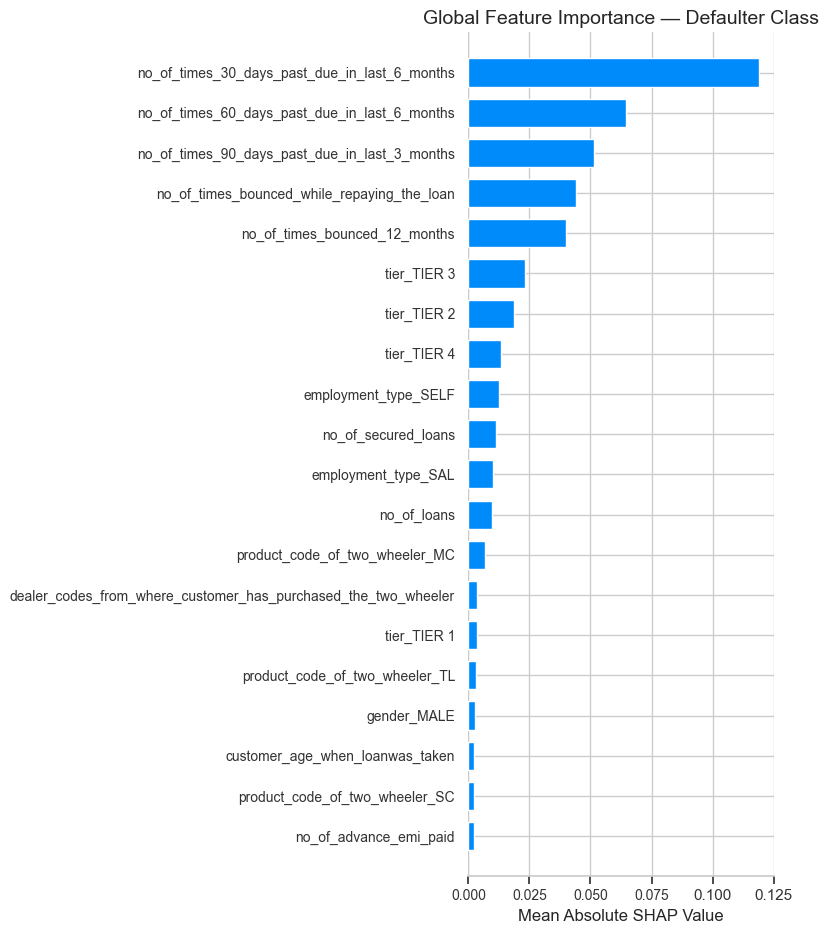

In [79]:
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_defaulter,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False  # prevents shap from auto-rendering so we can customize
)

plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.title('Global Feature Importance — Defaulter Class', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

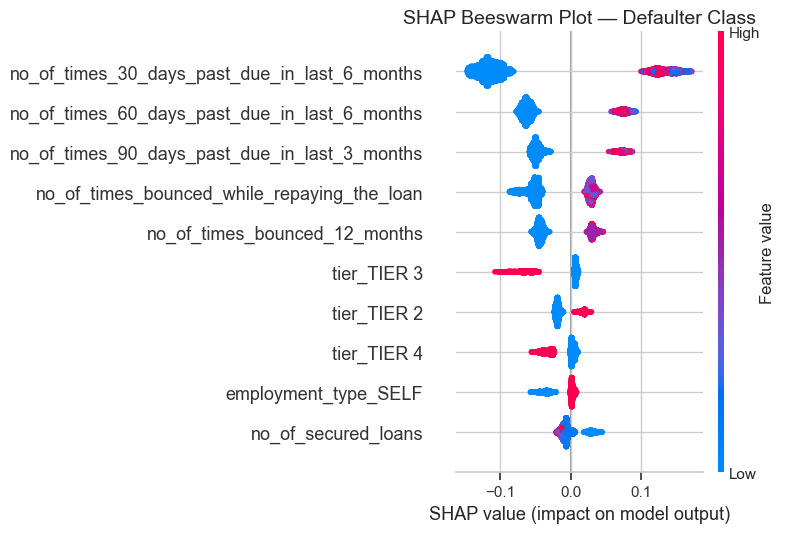

In [86]:
plt.figure(figsize=(30, 10))
shap.summary_plot(
    shap_values_defaulter,
    X_test_df,
    feature_names=feature_names,
    max_display=10,        # only show top 10 features
    show=False             
)
plt.title('SHAP Beeswarm Plot — Defaulter Class', fontsize=14)
plt.tight_layout()
plt.show()

In [87]:
y_pred = model.predict(X_test_df)
y_true = y_test.values.ravel()

false_negatives = np.where((y_pred == 0) & (y_true == 1))[0]
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]

print(f"Missed defaulters (False Negatives): {len(false_negatives)}")
print(f"Wrongly flagged (False Positives): {len(false_positives)}")

Missed defaulters (False Negatives): 152
Wrongly flagged (False Positives): 2126


d:\Machine_Learning_Foundations\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


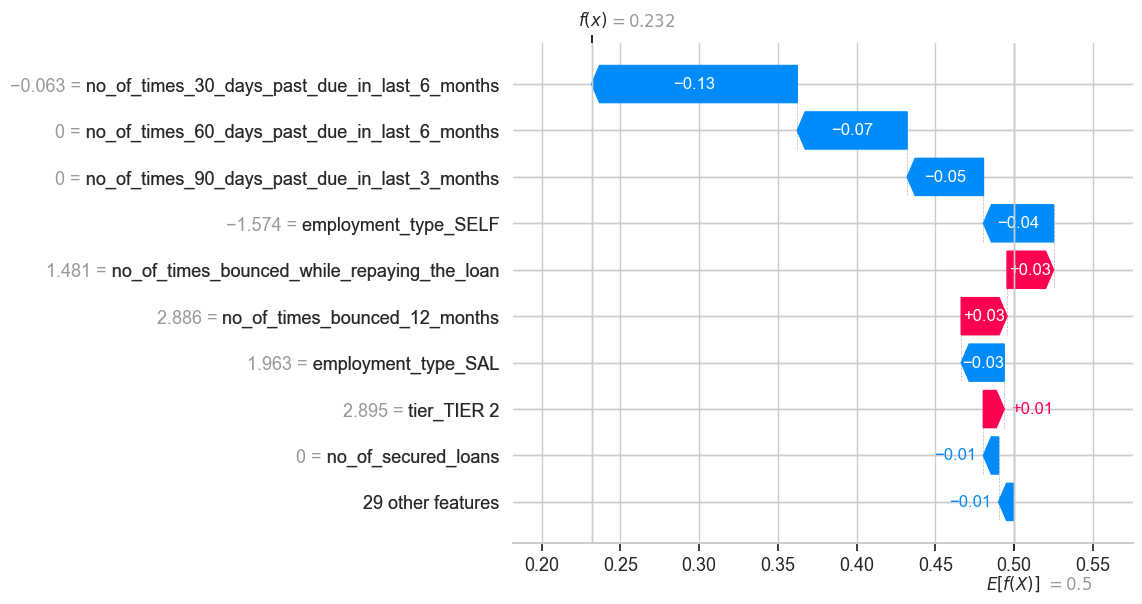

In [88]:
# look at first missed defaulter
shap.waterfall_plot(shap.Explanation(
    values=shap_values_defaulter[false_negatives[0]],
    base_values=explainer.expected_value[1],
    data=X_test_df.iloc[false_negatives[0]],
    feature_names=feature_names
))

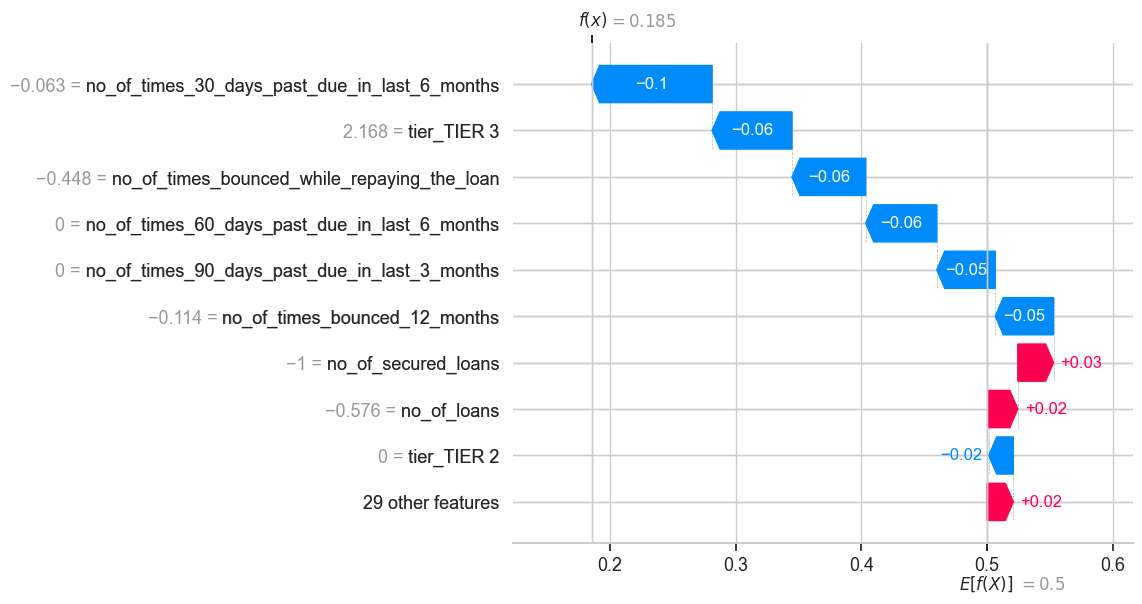

In [89]:
# look at a second missed defaulter
shap.waterfall_plot(shap.Explanation(
    values=shap_values_defaulter[false_negatives[1]],
    base_values=explainer.expected_value[1],
    data=X_test_df.iloc[false_negatives[1]],
    feature_names=feature_names
))

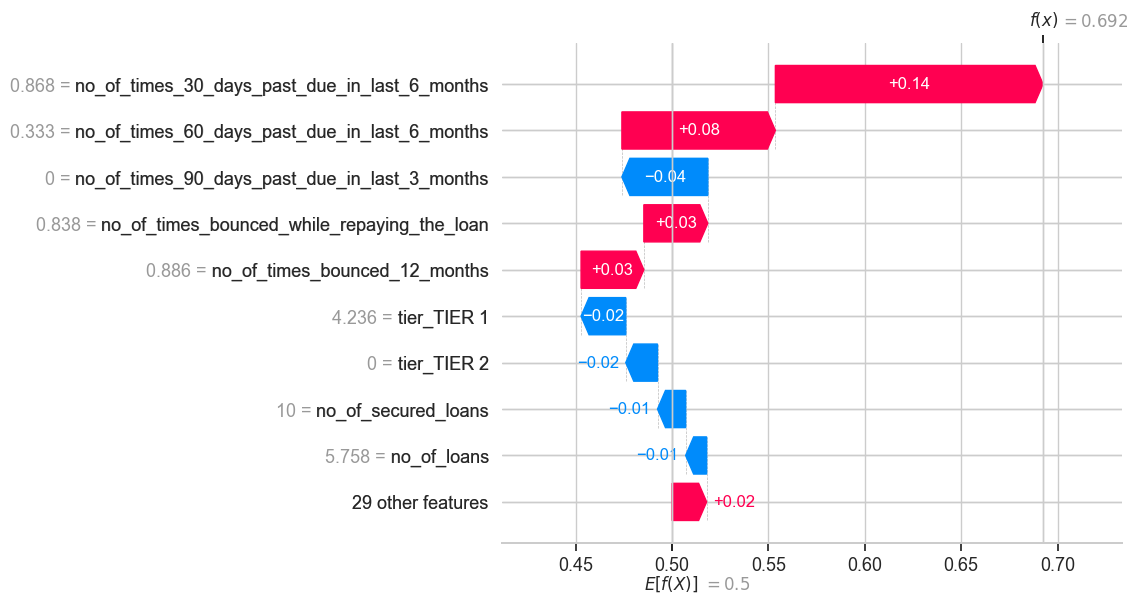

In [90]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values_defaulter[false_positives[0]],
    base_values=explainer.expected_value[1],
    data=X_test_df.iloc[false_positives[0]],
    feature_names=feature_names
))

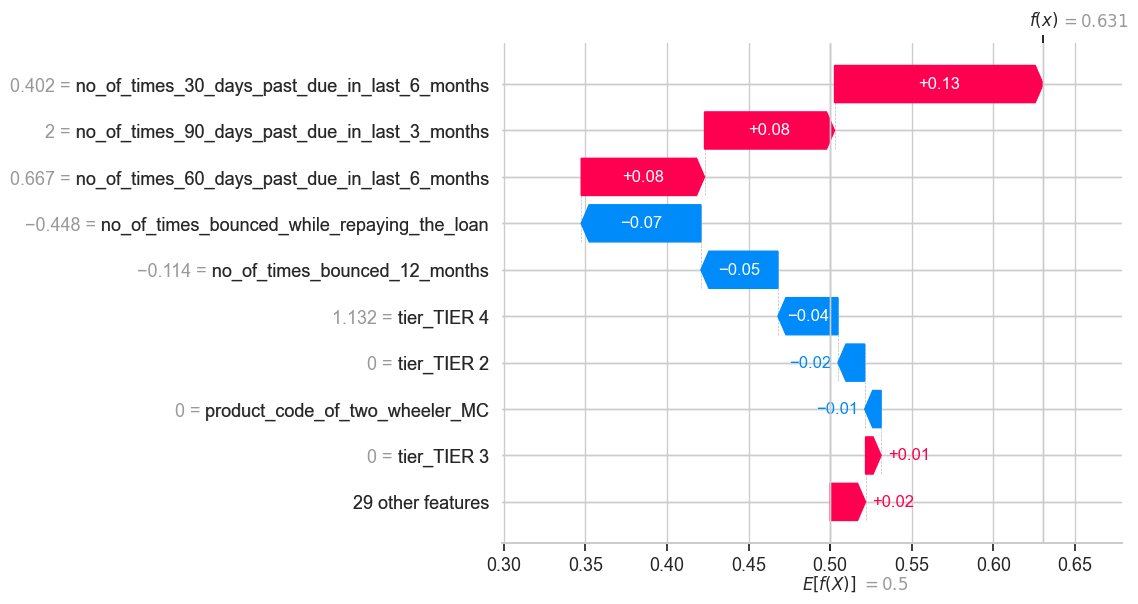

In [91]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values_defaulter[false_positives[3]],
    base_values=explainer.expected_value[1],
    data=X_test_df.iloc[false_positives[3]],
    feature_names=feature_names
))

If you do not want to do shap, just do a simple feature importance plot using the feature_importances_ attribute of the random forest model.

Feature: 0, Score: 0.02112
Feature: 1, Score: 0.00307
Feature: 2, Score: 0.00605
Feature: 3, Score: 0.01332
Feature: 4, Score: 0.03479
Feature: 5, Score: 0.00652
Feature: 6, Score: 0.08837
Feature: 7, Score: 0.02355
Feature: 8, Score: 0.09053
Feature: 9, Score: 0.01828
Feature: 10, Score: 0.02376
Feature: 11, Score: 0.02050
Feature: 12, Score: 0.02727
Feature: 13, Score: 0.03554
Feature: 14, Score: 0.01999
Feature: 15, Score: 0.02484
Feature: 16, Score: 0.04550
Feature: 17, Score: 0.04492
Feature: 18, Score: 0.02211
Feature: 19, Score: 0.00000
Feature: 20, Score: 0.01876
Feature: 21, Score: 0.20756
Feature: 22, Score: 0.12947
Feature: 23, Score: 0.07420


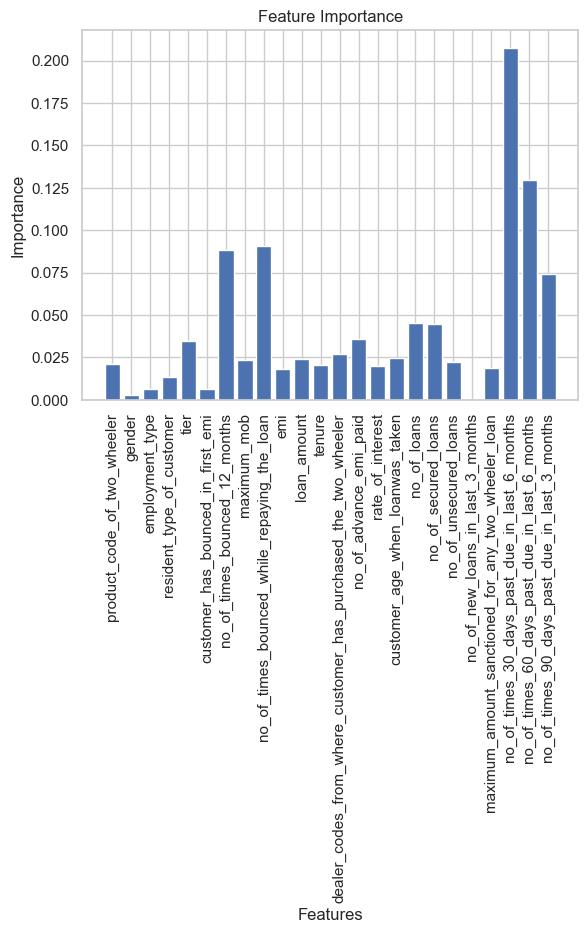

In [ ]:
# Get importance
importance = model.feature_importances_
# Summarize feature importance
for i, v in enumerate(importance):
    print(f'Feature: {i}, Score: {v:.5f}')

# Plot feature importance
plt.bar([x for x in range(len(importance))], importance)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks([x for x in range(len(importance))], data.columns[:-1], rotation=90)
plt.show()

In [ ]:
print(importance)

[0.02111557 0.00307286 0.00604777 0.01332305 0.03478856 0.00651744
 0.08837192 0.02355009 0.0905317  0.01827595 0.02376162 0.02050412
 0.02726764 0.03553702 0.01998956 0.02483525 0.04549809 0.04491704
 0.02210759 0.         0.01875635 0.20755557 0.1294745  0.07420076]


In [ ]:
#save the model

import pickle
filename = 'random_classifier.sav'
pickle.dump(model, open(filename, 'wb'))

# load the model
#rand_class= pickle.load(open(filename, 'rb')) <--use this to load the model

### Generaring Credit Scores

## Challenge: 
- Explore the linear separabillity of the two classes and document your intuition of the best model type to give you the best results. 
- Document the effect of multicolleaniarity in model performance. 
- Try different classification models and optimize your output for the best result
- Tune your model after learning these in Week 4 - The submission can be done without this step : It is worth noting that feature engineering is of much importance than hyperparametere tuning as the perfomance  improvement with the latter is always only marginal
- Generate Credit Scores based on the probability score from the model (Optional)
- Identify which customers fall into what category, based on the below ranking methodologies 
> #### The following forms our basis for rank ordering 
> - 0 - 200 Bad Customer ,
> - 201-350 2nd Worst, 
> - 351 - 500 Not So bad,
> - 501 - 700 Ideal guys, 
> - 700> Big loans 

